## Imports

In [1]:
import xarray as xr

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from xhistogram.xarray import histogram
import matplotlib.colors as colors
import cartopy.crs as ccrs
import scipy
import matplotlib.patches as patches

## Open the data

In [3]:
# data in persistent bucket
#target_url ='gs://leap-scratch/cspencerjones/hero-calc/masked_hist.zarr'



###target_url ='gs://leap-persistent/cspencerjones/hero-calc/compute/llc4320/masked_hist_48hr.zarr'
#target_url ='gs://leap-persistent/cspencerjones/hero-calc/compute/llc4320/masked_hist_renorm_48hr.zarr'

target_url ='gs://leap-persistent/cspencerjones/hero-calc/masked_hist_renorm_3hr.zarr'
#target_url2 = 'gs://leap-persistent/tomnicholas/hero-calc/compute/llc4320/vort_strain_div_histogram_coarsen_nan_padding_3_hourly.zarr'

In [4]:
hist_ds = xr.open_dataset(target_url, engine="zarr", chunks={})
#hist_ds2 = xr.open_dataset(target_url2, engine="zarr", chunks={})

In [5]:
hist_ds['histogram_vort_strain_div'].isel(time=0).nbytes / 1e9

1.678950504

In [6]:
hist_ds

<xarray.Dataset> Size: 62GB
Dimensions:                    (time: 37, region: 437, vort_bin: 99,
                                strain_bin: 49, div_bin: 99, vertices: 4)
Coordinates:
  * time                       (time) datetime64[ns] 296B 2011-09-17T22:30:00...
  * vort_bin                   (vort_bin) float64 792B -4.949 -4.848 ... 4.949
  * strain_bin                 (strain_bin) float64 392B 0.05102 ... 4.949
  * div_bin                    (div_bin) float64 792B -4.949 -4.848 ... 4.949
    j_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_longitude         (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
    region_num                 (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    i_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    face                       (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_latitude          (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
Dimensions without coordinates: region, vertices
Data variables:
    histogram_vort_strain_div  (time, region, vort_bin, strain_bin, div_bin) float64 62GB dask.array<chunksize=(1, 1, 99, 49, 99), meta=np.ndarray>

In [7]:
from xarray.indexes import PandasIndex

# have to add the index ourselves manually for some reason
hist_ds = hist_ds.set_xindex('region_num', PandasIndex)
#hist_ds2 = hist_ds2.set_xindex('region_num', PandasIndex)

In [8]:
hist_ds

<xarray.Dataset> Size: 62GB
Dimensions:                    (time: 37, region: 437, vort_bin: 99,
                                strain_bin: 49, div_bin: 99, vertices: 4)
Coordinates:
  * time                       (time) datetime64[ns] 296B 2011-09-17T22:30:00...
  * vort_bin                   (vort_bin) float64 792B -4.949 -4.848 ... 4.949
  * strain_bin                 (strain_bin) float64 392B 0.05102 ... 4.949
  * div_bin                    (div_bin) float64 792B -4.949 -4.848 ... 4.949
    j_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_longitude         (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
  * region_num                 (region) int64 3kB 4 5 6 7 13 ... 792 793 798 799
    i_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    face                       (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_latitude          (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
Dimensions without coordinates: region, vertices
Data variables:
    histogram_vort_strain_div  (time, region, vort_bin, strain_bin, div_bin) float64 62GB dask.array<chunksize=(1, 1, 99, 49, 99), meta=np.ndarray>

## Correct PDF normalization

Division by 80 comes from 8 samples per day (3-hourly sampling of hourly data) over a 10-day period. 
This correction is currently required because I accidentally did `coarsen(time=8*10).sum(dim='time')` instead of `coarsen(time=8*10).mean(dim='time')` before saving to zarr.

In [9]:
#hist_ds2['histogram_vort_strain_div'] = hist_ds2['histogram_vort_strain_div'] / 80

In [10]:
hist_ds['histogram_vort_strain_div'].isel(time=slice(11,20)).time

<xarray.DataArray 'time' (time: 9)> Size: 72B
array(['2012-01-05T22:30:00.000000000', '2012-01-15T22:30:00.000000000',
       '2012-01-25T22:30:00.000000000', '2012-02-04T22:30:00.000000000',
       '2012-02-14T22:30:00.000000000', '2012-02-24T22:30:00.000000000',
       '2012-03-05T22:30:00.000000000', '2012-03-15T22:30:00.000000000',
       '2012-03-25T22:30:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 72B 2012-01-05T22:30:00 ... 2012-03-25T22:...

## Basic quantities

In [11]:
#JFM
h = hist_ds['histogram_vort_strain_div'].isel(time=slice(11,20))
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')

#ASO
h_ASO = hist_ds['histogram_vort_strain_div'].roll(time=5,roll_coords=True).isel(time=slice(0,10))
h_ASO['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h_ASO['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h_ASO['center_lon'] = h_ASO['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1_ASO = h_ASO.mean('time')

In [12]:
right_half = (h1*h1.div_bin).where(h1.div_bin<0).isel(vort_bin=slice(50,100)).sum(['vort_bin','div_bin','strain_bin']).load()
total = (h1*h1.div_bin).where(h1.div_bin<0).sum(['vort_bin','div_bin','strain_bin']).load()

#put 50% of the vorticity in the zero bin into righthalf_plus
righthalf_plus = right_half + (h1*h1.div_bin).where(h1.div_bin<0).isel(vort_bin=49).sum(['div_bin','strain_bin']).load()/2

right_half_ASO = (h1_ASO*h1_ASO.div_bin).where(h1_ASO.div_bin<0).isel(vort_bin=slice(50,100)).sum(['vort_bin','div_bin','strain_bin']).load()
total_ASO = (h1_ASO*h1_ASO.div_bin).where(h1_ASO.div_bin<0).sum(['vort_bin','div_bin','strain_bin']).load()

righthalfASO_plus = right_half_ASO + (h1_ASO*h1_ASO.div_bin).where(h1_ASO.div_bin<0).isel(vort_bin=49).sum(['div_bin','strain_bin']).load()/2

KeyboardInterrupt: 

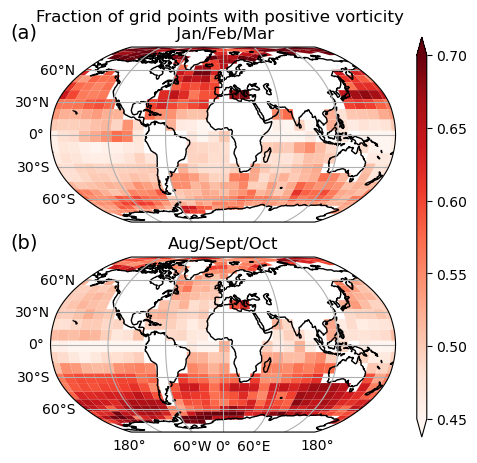

In [13]:
fig = plt.figure(figsize=(5, 5))
plt.clf()
ax = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalf_plus/total, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
ax.autoscale_view
#plt.colorbar(coll)
ax.gridlines(draw_labels=["left"])
plt.text(-2.1*10**7,0.95*10**7,'(a)',fontsize=14)
plt.title('Fraction of grid points with positive vorticity \n Jan/Feb/Mar')

ax3 = fig.add_subplot(2, 1, 2, projection=ccrs.Robinson())

ax3.set_global()

ax3.coastlines()

max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalfASO_plus/total_ASO, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax3.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
#ax2.autoscale_view
#plt.colorbar(coll)
ax3.gridlines(draw_labels=["bottom", "left"])
ax3.text(-2.1*10**7,0.95*10**7,'(b)',fontsize=14)
plt.title('Aug/Sept/Oct')


cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.8])
fig.colorbar(coll, cax=cbar_ax,extend='both')

plt.savefig('Frac-positive-vort.png')

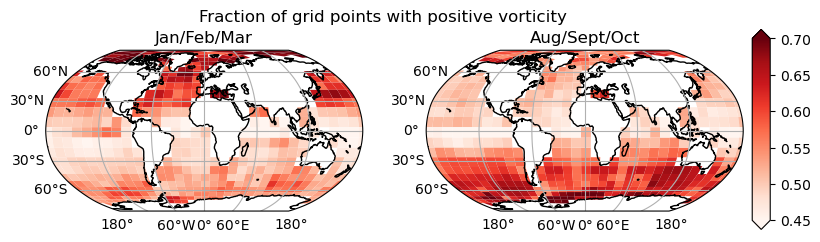

In [14]:
#poster_version
fig = plt.figure(figsize=(9, 2.5))
plt.clf()

ax = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalf_plus/total, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
ax.autoscale_view
#plt.colorbar(coll)
ax.gridlines(draw_labels=["bottom", "left"])
#plt.text(-2.1*10**7,0.95*10**7,'(a)',fontsize=14)
plt.title('Jan/Feb/Mar')

ax3 = fig.add_subplot(1, 2, 2, projection=ccrs.Robinson())

ax3.set_global()

ax3.coastlines()

max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalfASO_plus/total_ASO, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax3.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
#ax2.autoscale_view
#plt.colorbar(coll)
ax3.gridlines(draw_labels=["bottom", "left"])
#ax3.text(-2.1*10**7,0.95*10**7,'(b)',fontsize=14)
plt.title('Aug/Sept/Oct')

plt.suptitle('Fraction of grid points with positive vorticity') 


cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
fig.colorbar(coll, cax=cbar_ax,extend='both')

plt.savefig('Frac-positive-vort-poster.png')

In [13]:
hi_strain = (h1*h1.div_bin).where(h1.strain_bin>(np.abs(h1.vort_bin)+1.5)).sum(['vort_bin','div_bin','strain_bin']).load()
hi_strain_ASO = (h1_ASO*h1_ASO.div_bin).where(h1_ASO.strain_bin>(np.abs(h1_ASO.vort_bin)+1.5)).sum(['vort_bin','div_bin','strain_bin']).load()

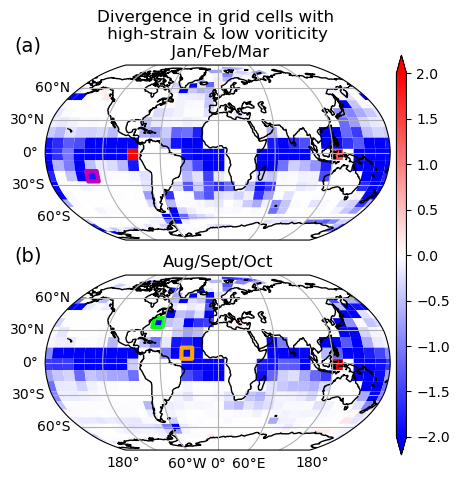

In [15]:
fig = plt.figure(figsize=(5, 5))
plt.clf()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)

ax2 = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson())

ax2.set_global()

ax2.coastlines()

coll = PolyCollection(verts, array=hi_strain, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax2.add_collection(coll)
coll.set_clim(-2,vmax=2)
ax2.autoscale_view
#plt.colorbar(coll)
ax2.gridlines(draw_labels=["left"])
plt.text(-2*10**7,10**7,'(a)',fontsize=14)
plt.title('Divergence in grid cells with \n high-strain & low voriticity \n Jan/Feb/Mar')



#col2 = PolyCollection(verts[43:44], array=hi_strain_ASO[43:44], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
col2 = PolyCollection(verts[282:283], array=hi_strain_ASO[282:283], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax2.add_collection(col2)
ax2.autoscale_view()



ax4 = fig.add_subplot(2, 1, 2, projection=ccrs.Robinson())

ax4.set_global()

ax4.coastlines()


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=hi_strain_ASO, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax4.add_collection(coll)
coll.set_clim(vmin=-2,vmax=2)
#ax2.autoscale_view
#plt.colorbar(coll)
ax4.gridlines(draw_labels=["bottom", "left"])
ax4.text(-2*10**7,10**7,'(b)',fontsize=14)
plt.title('Aug/Sept/Oct')

col2 = PolyCollection(verts[350:351], array=hi_strain_ASO[350:351], facecolors='none', linewidths=3, edgecolors='lime', transform=ccrs.PlateCarree())
ax4.add_collection(col2)
ax4.autoscale_view()

col2 = PolyCollection(verts[30:31], array=hi_strain_ASO[30:31], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
ax4.add_collection(col2)
ax4.autoscale_view()


#col2 = PolyCollection(verts[228:229], array=hi_strain_ASO[228:229], facecolors='none', linewidths=3, edgecolors='yellow', transform=ccrs.PlateCarree())
#ax4.add_collection(col2)
#ax4.autoscale_view()

cbar_ax = fig.add_axes([0.87, 0.1, 0.02, 0.8])
fig.colorbar(coll, cax=cbar_ax,extend='both')

plt.savefig('Div-hi-strain-map.png')

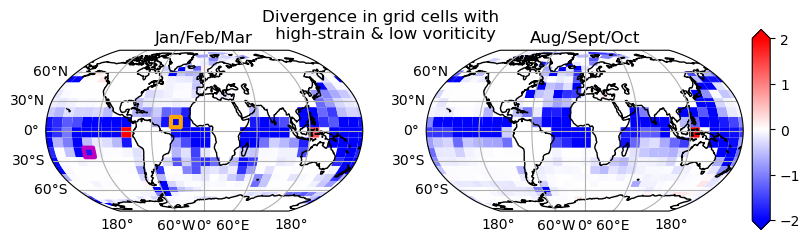

In [33]:
#poster_version
fig = plt.figure(figsize=(9, 2.5))
plt.clf()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)

ax2 = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())

ax2.set_global()

ax2.coastlines()

coll = PolyCollection(verts, array=hi_strain, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax2.add_collection(coll)
coll.set_clim(-2,vmax=2)
ax2.autoscale_view
#plt.colorbar(coll)
ax2.gridlines(draw_labels=["bottom","left"])
#plt.text(-2*10**7,10**7,'(a)',fontsize=14)
plt.title('Jan/Feb/Mar')

col2 = PolyCollection(verts[30:31], array=hi_strain_ASO[30:31], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
ax2.add_collection(col2)
ax2.autoscale_view()

#col2 = PolyCollection(verts[43:44], array=hi_strain_ASO[43:44], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
col2 = PolyCollection(verts[282:283], array=hi_strain_ASO[282:283], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax2.add_collection(col2)
ax2.autoscale_view()


ax4 = fig.add_subplot(1, 2, 2, projection=ccrs.Robinson())

ax4.set_global()

ax4.coastlines()


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=hi_strain_ASO, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax4.add_collection(coll)
coll.set_clim(vmin=-2,vmax=2)
#ax2.autoscale_view
#plt.colorbar(coll)
ax4.gridlines(draw_labels=["bottom", "left"])
#ax4.text(-2*10**7,10**7,'(b)',fontsize=14)
plt.title('Aug/Sept/Oct')

#col2 = PolyCollection(verts[350:351], array=hi_strain_ASO[350:351], facecolors='none', linewidths=3, edgecolors='lime', transform=ccrs.PlateCarree())
#ax4.add_collection(col2)
#ax4.autoscale_view()


#col2 = PolyCollection(verts[228:229], array=hi_strain_ASO[228:229], facecolors='none', linewidths=3, edgecolors='yellow', transform=ccrs.PlateCarree())
#ax4.add_collection(col2)
#ax4.autoscale_view()

plt.suptitle('Divergence in grid cells with \n high-strain & low voriticity')

cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
fig.colorbar(coll, cax=cbar_ax,extend='both')

plt.savefig('Div-hi-strain-map-poster.png')

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_815/1480635562.py:41: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Divergence when $\sigma>(|\zeta|+1.5|f|)$ \n Jan/Feb/Mar')


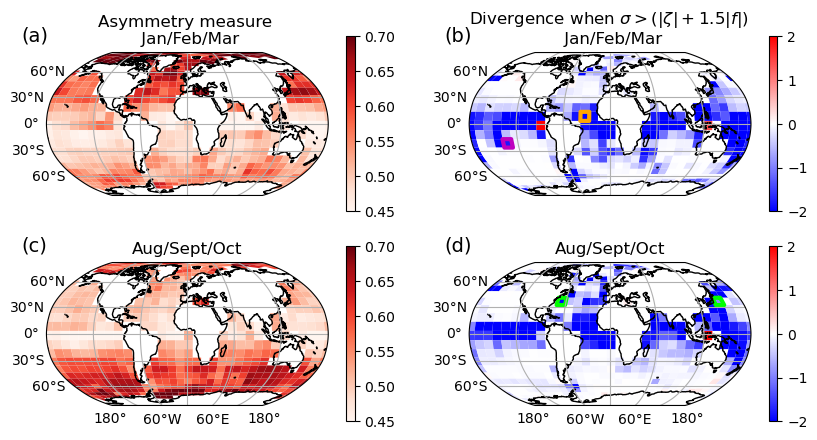

In [34]:
fig = plt.figure(figsize=(10, 5))
plt.clf()
ax = fig.add_subplot(2, 2, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalf_plus/total, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
ax.autoscale_view
plt.colorbar(coll)
ax.gridlines(draw_labels=["left"])
plt.text(-2*10**7,10**7,'(a)',fontsize=14)
plt.title('Asymmetry measure \n Jan/Feb/Mar')

ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.Robinson())

ax2.set_global()

ax2.coastlines()

coll = PolyCollection(verts, array=hi_strain, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax2.add_collection(coll)
coll.set_clim(-2,vmax=2)
ax2.autoscale_view
plt.colorbar(coll)
ax2.gridlines(draw_labels=["left"])
plt.text(-2*10**7,10**7,'(b)',fontsize=14)
plt.title('Divergence when $\sigma>(|\zeta|+1.5|f|)$ \n Jan/Feb/Mar')

col2 = PolyCollection(verts[30:31], array=hi_strain_ASO[30:31], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
ax2.add_collection(col2)
ax2.autoscale_view()

#col2 = PolyCollection(verts[43:44], array=hi_strain_ASO[43:44], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
col2 = PolyCollection(verts[282:283], array=hi_strain_ASO[282:283], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax2.add_collection(col2)
ax2.autoscale_view()





ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Robinson())

ax3.set_global()

ax3.coastlines()


max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalfASO_plus/total_ASO, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax3.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
#ax2.autoscale_view
plt.colorbar(coll)
ax3.gridlines(draw_labels=["bottom", "left"])
ax3.text(-2*10**7,10**7,'(c)',fontsize=14)
plt.title('Aug/Sept/Oct')


ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.Robinson())

ax4.set_global()

ax4.coastlines()


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=hi_strain_ASO, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax4.add_collection(coll)
coll.set_clim(vmin=-2,vmax=2)
#ax2.autoscale_view
plt.colorbar(coll)
ax4.gridlines(draw_labels=["bottom", "left"])
ax4.text(-2*10**7,10**7,'(d)',fontsize=14)
plt.title('Aug/Sept/Oct')

col2 = PolyCollection(verts[350:351], array=hi_strain_ASO[350:351], facecolors='none', linewidths=3, edgecolors='lime', transform=ccrs.PlateCarree())
ax4.add_collection(col2)
ax4.autoscale_view()


col2 = PolyCollection(verts[228:229], array=hi_strain_ASO[228:229], facecolors='none', linewidths=3, edgecolors='lime', transform=ccrs.PlateCarree())
ax4.add_collection(col2)
ax4.autoscale_view()




#plt.savefig('Frac-conv-positive-vort.png')

In [14]:
hi_strain_ASO.center_lat.where((hi_strain_ASO.center_lat>-20) & (hi_strain_ASO.center_lat<0)).dropna('region').region_num

<xarray.DataArray 'region_num' (region: 45)> Size: 360B
array([ 69,  70,  77,  78,  85,  86,  93,  94, 125, 126, 261, 262, 269, 270,
       277, 278, 285, 286, 293, 301, 310, 520, 521, 522, 523, 524, 525, 526,
       527, 528, 529, 530, 531, 532, 533, 534, 535, 712, 713, 714, 715, 720,
       721, 722, 723])
Coordinates:
    j_region_coarse  (region) int64 360B 5 6 5 6 5 6 5 6 5 ... 7 0 1 2 3 0 1 2 3
  * region_num       (region) int64 360B 69 70 77 78 85 ... 715 720 721 722 723
    i_region_coarse  (region) int64 360B 0 0 1 1 2 2 3 3 7 ... 2 1 1 1 1 2 2 2 2
    face             (region) int64 360B 1 1 1 1 1 1 1 ... 11 11 11 11 11 11 11
    center_lat       (region) float32 180B -12.0 -1.728 -12.0 ... -12.0 -12.0
    center_lon       (region) float32 180B -32.38 -32.38 ... -99.88 -88.62
Dimensions without coordinates: region

In [16]:
verts[282:283]

array([[[-139.23958 ,  -17.074287],
        [-139.23958 ,  -26.641497],
        [-128.01042 ,  -26.641497],
        [-128.01042 ,  -17.074287]]], dtype=float32)

In [24]:
verts[30:31]

array([[[-37.989582 ,   3.4877594],
        [-26.760416 ,   3.4877594],
        [-26.760416 ,  13.728166 ],
        [-37.989582 ,  13.728166 ]]], dtype=float32)

In [30]:
verts[350:351]

array([[[-71.739586,  40.941288],
        [-71.739586,  32.650574],
        [-60.510418,  32.650574],
        [-60.510418,  40.941288]]], dtype=float32)

In [32]:
verts[236:237]

array([[[142.01042 ,  32.634415],
        [142.01042 ,  23.537529],
        [153.23958 ,  23.537529],
        [153.23958 ,  32.634415]]], dtype=float32)

In [33]:
verts[228:229]

array([[[142.01042 ,  40.941288],
        [142.01042 ,  32.650574],
        [153.23958 ,  32.650574],
        [153.23958 ,  40.941288]]], dtype=float32)

In [98]:
(np.log(ASO_vort_only.isel(region=290))+12).where(np.isfinite(np.log(ASO_vort_only.isel(region=290))), np.nan).fillna(0).reduce(func=scipy.stats.skew,dim="vort_bin",nan_policy='omit')

<xarray.DataArray ()> Size: 8B
array(0.04471523)
Coordinates:
    face             int64 8B dask.array<chunksize=(), meta=np.ndarray>
    i_region_coarse  int64 8B dask.array<chunksize=(), meta=np.ndarray>
    j_region_coarse  int64 8B dask.array<chunksize=(), meta=np.ndarray>
    region_num       int64 8B 553
    center_lat       float32 4B dask.array<chunksize=(), meta=np.ndarray>
    center_lon       float32 4B dask.array<chunksize=(), meta=np.ndarray>
    strain_bin       float64 8B 0.1531
    div_bin          float64 8B -4.848

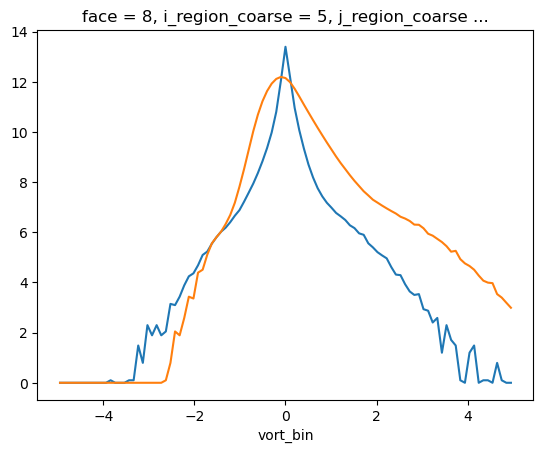

In [96]:
(np.log(ASO_vort_only.isel(region=190))+12).where(np.isfinite(np.log(ASO_vort_only.isel(region=190))), np.nan).fillna(0).plot()
(np.log(ASO_vort_only.isel(region=290))+12).where(np.isfinite(np.log(ASO_vort_only.isel(region=290))), np.nan).fillna(0).plot()
#np.log(ASO_vort_only).where(np.isfinite(np.log(ASO_vort_only)), np.nan).isel(region=290).values#.reduce(func=scipy.stats.skew,dim="vort_bin",nan_policy='omit')

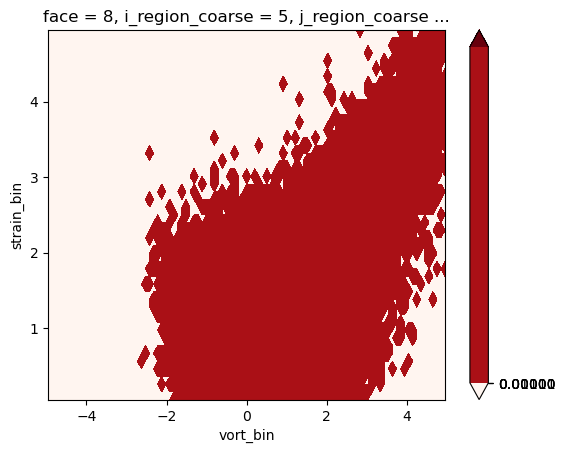

In [85]:
from matplotlib import colors as cols
#.plot(x='vort_bin')
levels = 10**(np.arange(-5.5, -1.5, 0.01))
h1_ASO.isel(region=290).sum('div_bin').plot.contourf(x='vort_bin',norm=cols.SymLogNorm(1e-7), cmap='Reds',
                    vmin=10**-5.5,extend='both',cbar_kwargs={'ticks': [10**-5, 10**-4, 10**-3, 10**-2],'label':''})

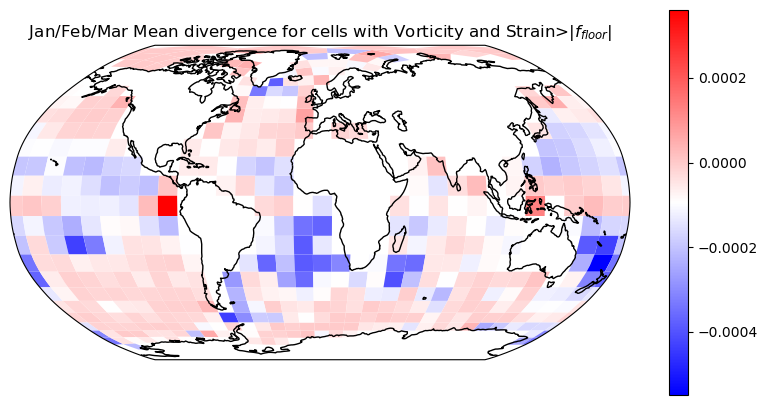

In [23]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=div_gt_val, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
#coll.set_clim(vmin=-0.2,vmax=0.2)
ax.autoscale_view
plt.colorbar(coll)



#highlight region
#col2 = PolyCollection(verts[76:77], array=hi_vs_jfm[76:77], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
#ax.add_collection(col2)
#ax.autoscale_view()

#col3 = PolyCollection(verts[9:10], array=hi_vs_jfm[9:10], facecolors='none', linewidths=3, edgecolors='g', transform=ccrs.PlateCarree())
#ax.add_collection(col3)
#ax.autoscale_view()

#col4 = PolyCollection(verts[254:255], array=hi_vs_jfm[232:233], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
#ax.add_collection(col4)
#ax.autoscale_view()


plt.title('Jan/Feb/Mar Mean divergence for cells with Vorticity and Strain>$|f_{floor}|$')
plt.savefig('JFM_div_hi-strain.png')

In [11]:
h = hist_ds['histogram_vort_strain_div']
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')

In [12]:
h1_2d

NameError: name 'h1_2d' is not defined

<>:45: SyntaxWarning: invalid escape sequence '\z'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\z'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_137/1556009727.py:45: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_137/1556009727.py:46: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma/f_{floor}$')


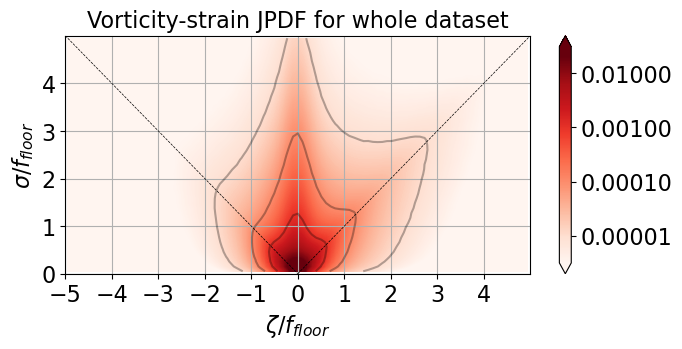

In [14]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

from matplotlib import cm, ticker
from matplotlib import colors as cols
h1_2d = (h1.sum('div_bin').mean('region')/970).load()

plt.figure(figsize=(7.5,3.5))
levels = 10**(np.arange(-5.5, -1.5, 0.01))
h1_2d.plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-7), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',cbar_kwargs={'ticks': [10**-5, 10**-4, 10**-3, 10**-2],'label':''})

h1_2d.plot.contour(x='vort_bin',levels=[1e-3, 1e-4, 1e-5], colors='k', alpha=.3)

#plt.contour(h1_2d.vort_bin, h1_2d.strain_bin, h1_2d, levels=[1e-5], colors='k', alpha=.3)



ax=plt.gca()

plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5,linestyle='--')
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5,linestyle='--')
# Create a Rectangle patch
#rect = patches.Rectangle((0.8, 0.8), 5, 5, linewidth=1, edgecolor='k', facecolor='none',linestyle='--')

# Add the patch to the Axes
#ax.add_patch(rect)

## Create a Rectangle patch
#rect = patches.Rectangle((-0.5, 1), 1, 4, linewidth=1, edgecolor='k', facecolor='none',linestyle='--')

# Add the patch to the Axes
#ax.add_patch(rect)

x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)

ax.set_xticks(x_ticks)

ax.set_yticks(y_ticks)


plt.xlim(-5,5)
plt.ylim(0,5)
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')
plt.rc('grid', color='black', alpha=.3)
plt.grid()

plt.subplots_adjust(bottom=0.2)

plt.title('Vorticity-strain JPDF for whole dataset',fontsize=16)
plt.savefig('vort-strain-complete.png')

<>:33: SyntaxWarning: invalid escape sequence '\z'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\z'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_178/2771116419.py:33: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_178/2771116419.py:34: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma/f_{floor}$')


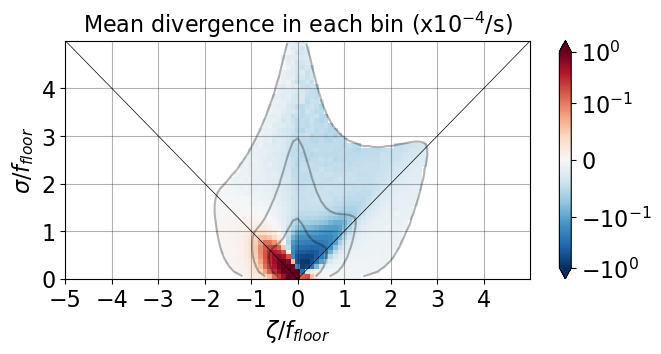

In [58]:
#div_2d = ((h1.div_bin*h1).mean('div_bin').mean('region')/970).load()
div_2d_masked = div_2d.where(h1_2d>10**-5)
#levels = 10**(np.arange(-5.5, -1.5, 0.1))
levels = 10**(np.arange(-5.5, -1.5, 0.1))

plt.figure(figsize=(7.5,3.5))
#h1_2d.plot.contour(x='vort_bin',
#                    vmin=10**-5.5,levels=levels,colors='k',linewidths=0.1)

h1_2d.plot.contour(x='vort_bin',levels=[1e-3, 1e-4, 1e-5], colors='k', alpha=.3)

(div_2d_masked*10**5).plot(x='vort_bin',vmax=1, norm=cols.SymLogNorm(1e-1), extend='both', cmap='RdBu_r')


plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
ax=plt.gca()

# Create a Rectangle patch
#rect = patches.Rectangle((1, 1), 5, 5, linewidth=1, edgecolor='k', facecolor='none',linestyle='--')

# Add the patch to the Axes
#ax.add_patch(rect)

## Create a Rectangle patch
#rect = patches.Rectangle((-0.5, 1), 1, 4, linewidth=1, edgecolor='k', facecolor='none',linestyle='--')

# Add the patch to the Axes
#ax.add_patch(rect)

plt.xlim(-5,5)
plt.ylim(0,5)
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')
plt.grid()

x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)

ax.set_xticks(x_ticks)

ax.set_yticks(y_ticks)

plt.subplots_adjust(bottom=0.2)

plt.title('Mean divergence in each bin (x$ 10^{-4}$/s)',fontsize=16)
plt.savefig('div-weighted-complete.png')

In [19]:
#ASO
h = hist_ds['histogram_vort_strain_div'].roll(time=5,roll_coords=True).isel(time=slice(0,10))
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')
h_gt_f = h1.where(h1.strain_bin>1).sum('strain_bin')
vs_gt_f_jfm = h1.where((h1.strain_bin>1) & (h1.vort_bin>1))
ds_gt_f_jfm = h1.where((h1.strain_bin>1) & (h1.div_bin>1))

hi_vs_jfm = (vs_gt_f_jfm.sum('strain_bin').sum('vort_bin').sum('div_bin')/970).load()
hi_vs_div_jfm1 = vs_gt_f_jfm.sum('strain_bin').sum('vort_bin')#.sum('div_bin')/970
hi_vs_div_jfm = (hi_vs_div_jfm1*hi_vs_div_jfm1.div_bin).mean('div_bin')#.load()

#hi_ds_jfm = (ds_gt_f_jfm.sum('strain_bin').sum('vort_bin').sum('div_bin')/970).load()
#hi_ds_vort_jfm1 = vs_gt_f_jfm.sum('strain_bin').sum('vort_bin')#.sum('div_bin')/970
#hi_ds_vort_jfm = (hi_ds_vort_jfm1*hi_ds_vort_jfm1.vort_bin).mean('vort_bin').load()

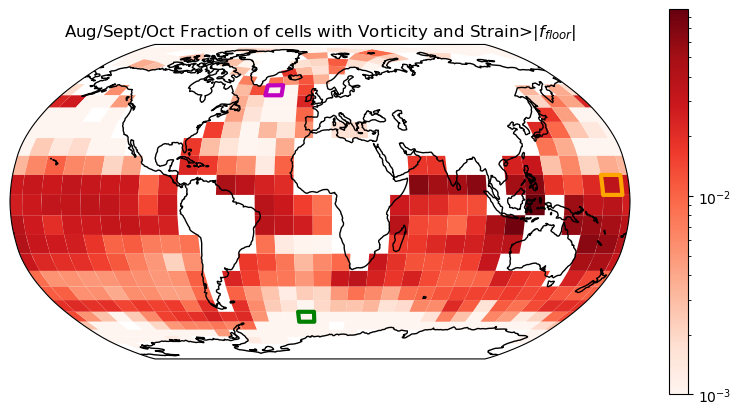

In [20]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=hi_vs_jfm, cmap='Reds', edgecolors='none', norm=mpl.colors.LogNorm(), transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=10**-3)
ax.autoscale_view
plt.colorbar(coll)



#highlight region
col2 = PolyCollection(verts[76:77], array=hi_vs_jfm[76:77], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax.add_collection(col2)
ax.autoscale_view()

col3 = PolyCollection(verts[9:10], array=hi_vs_jfm[9:10], facecolors='none', linewidths=3, edgecolors='g', transform=ccrs.PlateCarree())
ax.add_collection(col3)
ax.autoscale_view()

col4 = PolyCollection(verts[254:255], array=hi_vs_jfm[232:233], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
ax.add_collection(col4)
ax.autoscale_view()

plt.title('Aug/Sept/Oct Fraction of cells with Vorticity and Strain>$|f_{floor}|$')
plt.savefig('ASO_hi-strain.png')

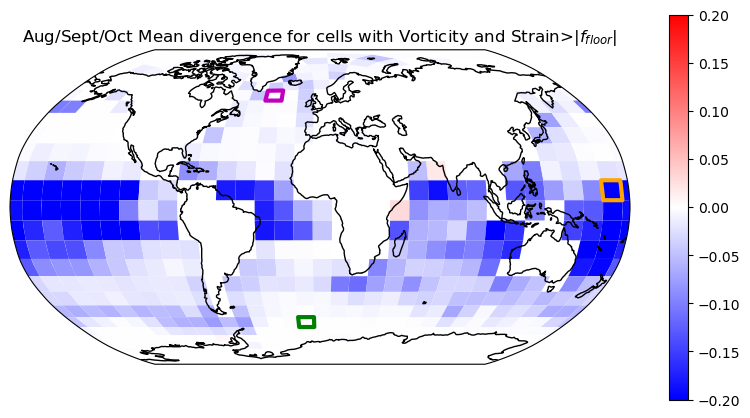

In [21]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=hi_vs_div_jfm, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=-0.2,vmax=0.2)
ax.autoscale_view
plt.colorbar(coll)



#highlight region
col2 = PolyCollection(verts[76:77], array=hi_vs_jfm[76:77], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax.add_collection(col2)
ax.autoscale_view()

col3 = PolyCollection(verts[9:10], array=hi_vs_jfm[9:10], facecolors='none', linewidths=3, edgecolors='g', transform=ccrs.PlateCarree())
ax.add_collection(col3)
ax.autoscale_view()

col4 = PolyCollection(verts[254:255], array=hi_vs_jfm[232:233], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
ax.add_collection(col4)
ax.autoscale_view()


plt.title('Aug/Sept/Oct Mean divergence for cells with Vorticity and Strain>$|f_{floor}|$')
plt.savefig('ASO_div_hi-strain.png')

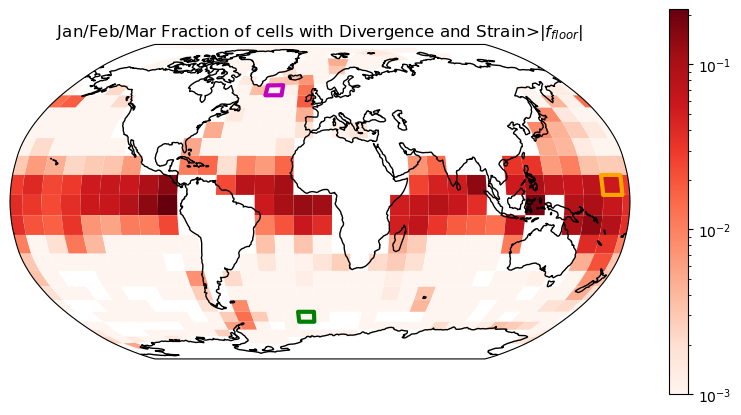

In [270]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=hi_ds_jfm, cmap='Reds', edgecolors='none', norm=mpl.colors.LogNorm(), transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=10**-3)
ax.autoscale_view
plt.colorbar(coll)



#highlight region
col2 = PolyCollection(verts[76:77], array=variance_div_jfm[76:77], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax.add_collection(col2)
ax.autoscale_view()

col3 = PolyCollection(verts[9:10], array=variance_div[9:10], facecolors='none', linewidths=3, edgecolors='g', transform=ccrs.PlateCarree())
ax.add_collection(col3)
ax.autoscale_view()

col4 = PolyCollection(verts[254:255], array=variance_div[232:233], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
ax.add_collection(col4)
ax.autoscale_view()


plt.title('Jan/Feb/Mar Fraction of cells with Divergence and Strain>$|f_{floor}|$')
plt.savefig('JFM_hi-div.png')

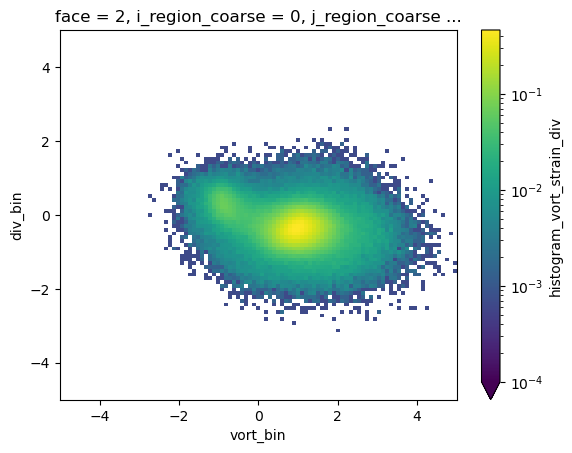

In [229]:
h_gt_f_jfm.sel(region=76).plot(x='vort_bin', vmin=10**-4, norm=mpl.colors.LogNorm())

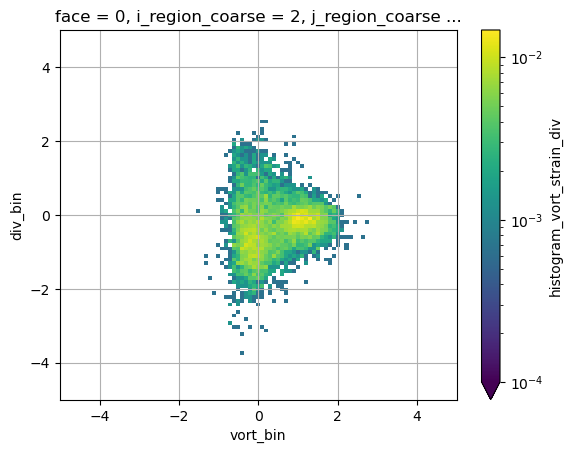

In [258]:
h_gt_f_jfm.isel(region=9).plot(x='vort_bin', vmin=10**-4, norm=mpl.colors.LogNorm())
plt.grid()

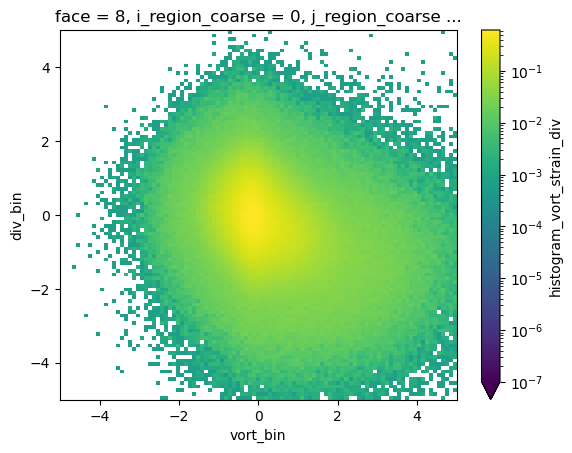

In [271]:
h_gt_f_jfm.isel(region=255).plot(x='vort_bin', vmin=10**-7, norm=mpl.colors.LogNorm())

In [132]:
variance_div_jfm = h_gt_f.sum('vort_bin').var('div_bin').load()#.isel(region=200).plot(y='div_bin', vmin=10**-6,vmax=1, norm=mpl.colors.LogNorm(),cmap='Reds')

<>:41: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_378/1751179385.py:41: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Jan/Feb/Mar Variance($\delta/f_{floor}$)')


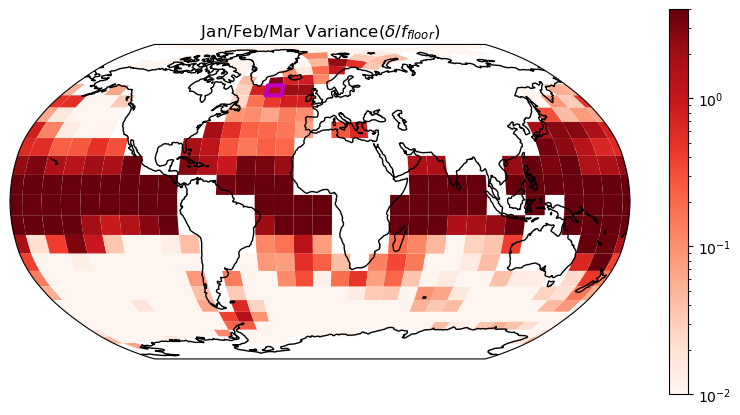

In [149]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=variance_div_jfm, cmap='Reds', edgecolors='none', norm=mpl.colors.LogNorm(), transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=10**-2, vmax=4)
ax.autoscale_view()
plt.colorbar(coll)



#highlight region
col2 = PolyCollection(verts[76:77], array=variance_div_jfm[76:77], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax.add_collection(col2)
ax.autoscale_view()


#col3 = PolyCollection(verts[260:261], array=variance_div[260:261], facecolors='none', linewidths=3, edgecolors='g', transform=ccrs.PlateCarree())
#ax.add_collection(col3)
#ax.autoscale_view()

#col4 = PolyCollection(verts[232:233], array=variance_div[232:233], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
#ax.add_collection(col4)
#ax.autoscale_view()


plt.title('Jan/Feb/Mar Variance($\delta/f_{floor}$)')
plt.savefig('JFM_div_variance.png')

In [18]:
#ASO
h = hist_ds['histogram_vort_strain_div'].roll(time=5,roll_coords=True).isel(time=slice(0,10))
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')
h_gt_f = h1.where(h1.strain_bin>1).sum('strain_bin')

In [151]:
variance_div_aso = h_gt_f.sum('vort_bin').var('div_bin').load()

<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_378/2185074385.py:29: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Aug/Sept/Oct Variance($\delta/f_{floor}$)')


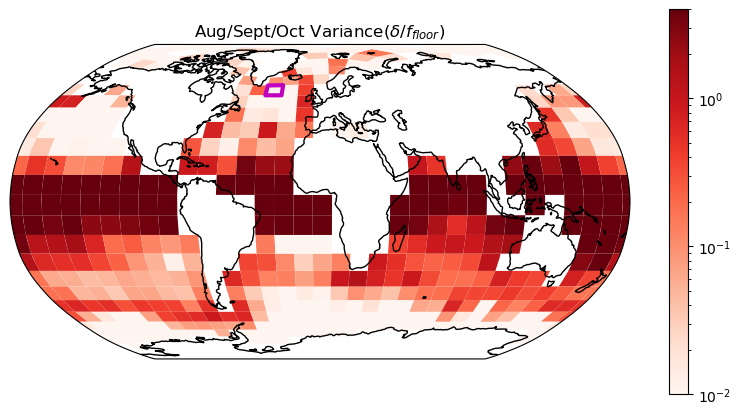

In [152]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=variance_div_aso, cmap='Reds', edgecolors='none', norm=mpl.colors.LogNorm(), transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=10**-2, vmax=4)
ax.autoscale_view()
plt.colorbar(coll)

#highlight region
col2 = PolyCollection(verts[76:77], array=variance_div_jfm[76:77], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax.add_collection(col2)
ax.autoscale_view()

plt.title('Aug/Sept/Oct Variance($\delta/f_{floor}$)')
plt.savefig('ASO_div_variance.png')

In [162]:
#JFM
h = hist_ds['histogram_vort_strain_div'].isel(time=slice(11,20))
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')
h_gt_f_jfm = h1.where(h1.strain_bin>1).sum('strain_bin')

In [154]:
variance_vort_jfm = h_gt_f_jfm.sum('div_bin').reduce(func=scipy.stats.skew,dim="vort_bin")

<>:29: SyntaxWarning: invalid escape sequence '\z'
<>:29: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_378/3898405665.py:29: SyntaxWarning: invalid escape sequence '\z'
  plt.title('Jan/Feb/Mar Skewness($\zeta/f_{floor}$)')


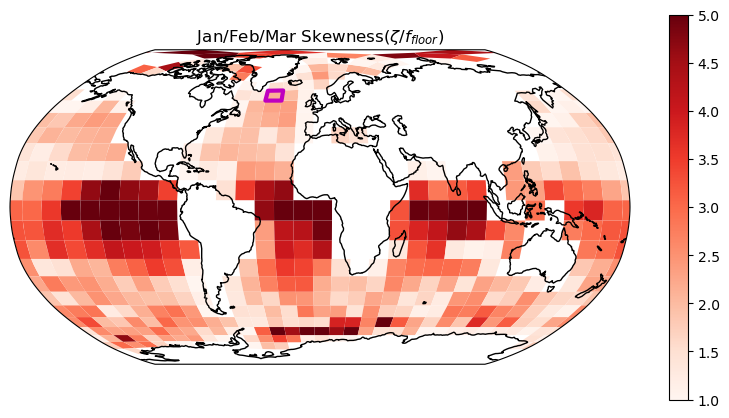

In [155]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=variance_vort_jfm, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=1,vmax=5)#, norm=mpl.colors.LogNorm()vmin=10**-2, vmax=4
ax.autoscale_view()
plt.colorbar(coll)

#highlight region
col2 = PolyCollection(verts[76:77], array=variance_div_jfm[76:77], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax.add_collection(col2)
ax.autoscale_view()

plt.title('Jan/Feb/Mar Skewness($\zeta/f_{floor}$)')
plt.savefig('JFM_vort_skewness.png')

In [164]:
#ASO
h = hist_ds['histogram_vort_strain_div'].roll(time=5,roll_coords=True).isel(time=slice(0,10))
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')
h_gt_f_aso = h1.where(h1.strain_bin>1).sum('strain_bin')

In [157]:
variance_vort_aso = h_gt_f_aso.sum('div_bin').reduce(func=scipy.stats.skew,dim="vort_bin")

<>:29: SyntaxWarning: invalid escape sequence '\z'
<>:29: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_378/2981790856.py:29: SyntaxWarning: invalid escape sequence '\z'
  plt.title('Aug/Sept/Oct Skewness($\zeta/f_{floor}$)')


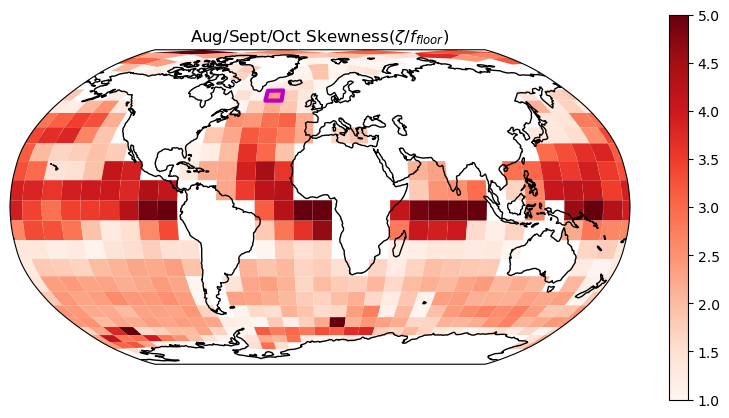

In [158]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=variance_vort_aso, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=1,vmax=5)#, norm=mpl.colors.LogNorm()vmin=10**-2, vmax=4
ax.autoscale_view()
plt.colorbar(coll)

#highlight region
col2 = PolyCollection(verts[76:77], array=variance_div_jfm[76:77], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax.add_collection(col2)
ax.autoscale_view()

plt.title('Aug/Sept/Oct Skewness($\zeta/f_{floor}$)')
plt.savefig('ASO_vort_skewness.png')

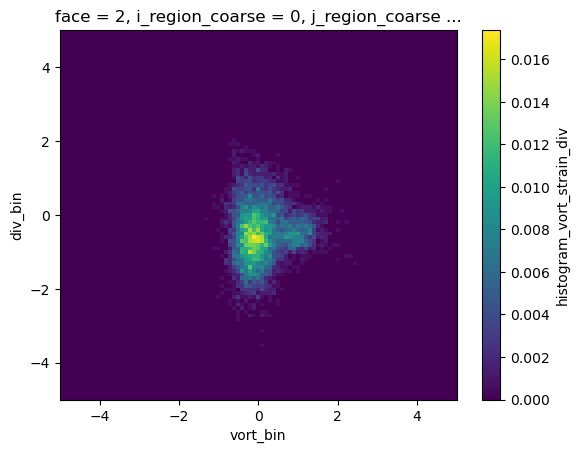

In [167]:
h_gt_f_aso.isel(region=76).plot(x='vort_bin')

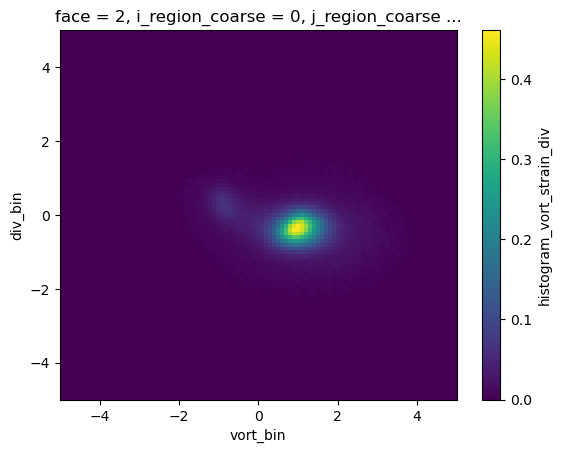

In [168]:
h_gt_f_jfm.isel(region=76).plot(x='vort_bin')

## If we just slice based on f

In [12]:
#hist_ds2.isel(time=0, region=401).vertices_longitude.values#['histogram_vort_strain_div'].isel(time=0, region=64).

In [13]:
hist_ds.isel(time=0, region=400).vertices_longitude.values#['histogram_vort_strain_div'].isel(time=0, region=64).time

array([-82.989586, -82.989586, -71.760414, -71.760414], dtype=float32)

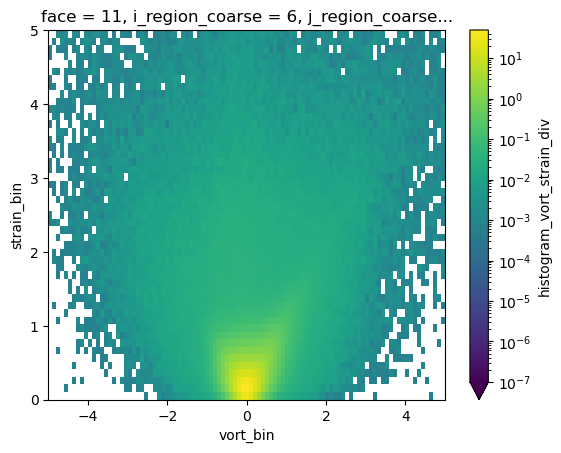

In [14]:
hist_ds['histogram_vort_strain_div'].isel(region=400).mean('time').sum('div_bin').plot(y='strain_bin', vmin=10**-7, norm=mpl.colors.LogNorm())

In [15]:
#hist_ds['histogram_vort_strain_div'].isel(time=10, region=70).sum().values

In [57]:

h = hist_ds['histogram_vort_strain_div']#.sel(region=slice(0,200))#.sel(region=230)
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')#.isel(strain_bin=10)
h1['theta'] = np.arctan2(h1['div_bin'],h1['vort_bin'])+np.pi
#h1['theta'] = (h1['theta'].where(h1['div_bin']<0, h1['theta']+np.pi)+np.pi/2)

bins = np.linspace(0, 2*np.pi, 21)
weights=h1.fillna(0)


#MUST FIX THIS SO WE ARE CONSISTENTLY PICKING VALUES WITH strain>f
h2 = histogram(h1['theta'], bins=bins,weights=weights, dim=['div_bin','vort_bin'])
h_gt_f = h2.where(h1.strain_bin>1).sum('strain_bin')
h1_gt_f = h1.where(h1.strain_bin>1).sum('strain_bin')
#h_gt_f = h2.isel(strain_bin=slice(10,50)).sum('strain_bin')


In [58]:
max1 = h_gt_f.argmax('theta_bin').load()

In [59]:
#h2.isel(region=0).plot(norm=colors.LogNorm(), vmin=1e-2)

In [60]:
peakiness = ((h_gt_f.max('theta_bin')-h_gt_f.min('theta_bin'))/h_gt_f.min('theta_bin')).load()
#write_peakiness = peakiness.to_dataset()
#write_peakiness = write_peakiness.assign_coords({"center_lon": h['center_lon']})
#write_peakiness['center_lon']=h['center_lon']
#write_peakiness.to_netcdf('peakiness1.nc')

In [61]:
#write_peakiness
#read_peakiness = xr.open_dataset('peakiness1.nc')
import cartopy.crs as ccrs

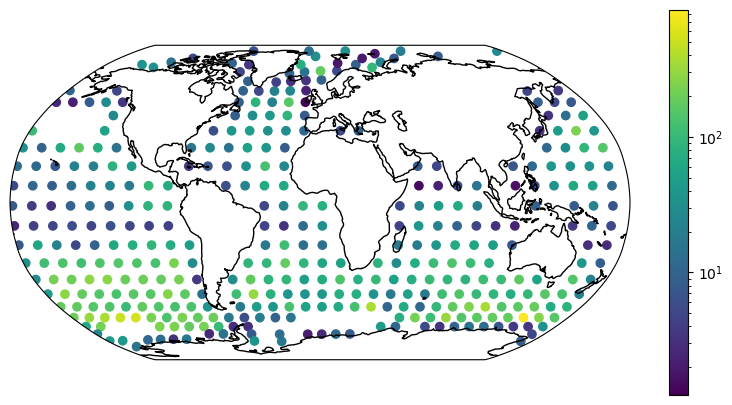

In [22]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()

cs = plt.scatter(x=h['center_lon'], y=h['center_lat'], c=peakiness, norm=mpl.colors.LogNorm(), transform=ccrs.PlateCarree())
plt.colorbar(cs)

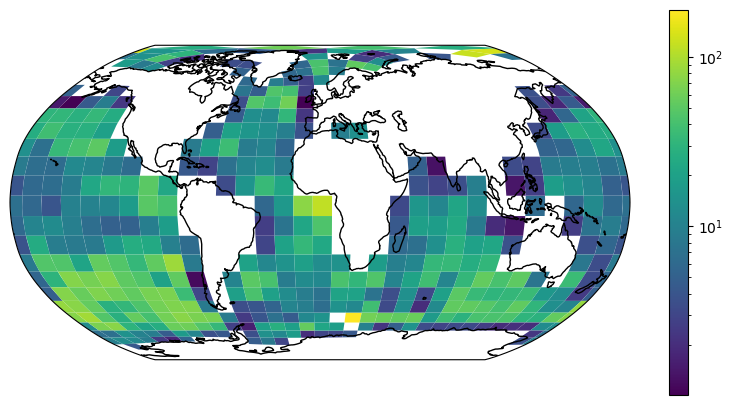

In [19]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)
# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=peakiness, cmap='viridis', edgecolors='none', norm=mpl.colors.LogNorm(), transform=ccrs.PlateCarree())
ax.add_collection(coll)
ax.autoscale_view()
plt.colorbar(coll)
plt.gcf().savefig('peakiness.png')

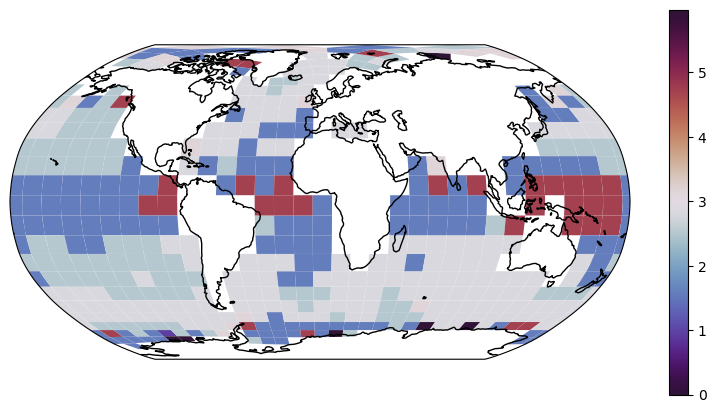

In [62]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()

from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)
# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=bins[max1], cmap='twilight_shifted', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
ax.autoscale_view()
plt.colorbar(coll)
plt.gcf().savefig('angle.png')

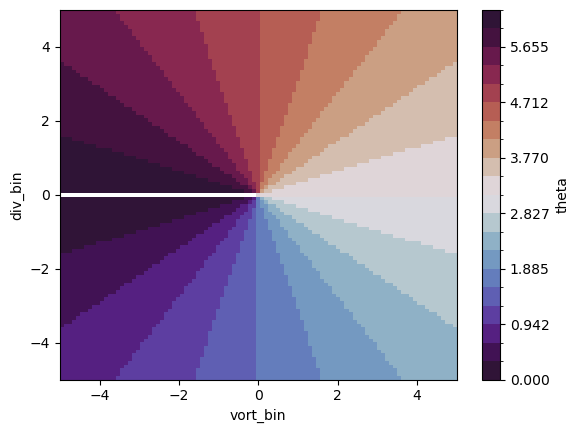

In [63]:
h1['theta'].plot(levels=bins, cmap = 'twilight_shifted')
plt.gcf().savefig('angle_key.png')

In [64]:
#SON
h = hist_ds['histogram_vort_strain_div'].isel(time=slice(0,8))#.sel(region=230)
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')#.isel(strain_bin=10)
h1['theta'] = np.arctan2(h1['div_bin'],h1['vort_bin'])+np.pi


bins = np.linspace(0, 2*np.pi, 21)
weights=h1.fillna(0)


#MUST FIX THIS SO WE ARE CONSISTENTLY PICKING VALUES WITH strain>f
h2 = histogram(h1['theta'], bins=bins,weights=weights, dim=['div_bin','vort_bin'])
h_gt_f = h2.where(h1.strain_bin>1).sum('strain_bin')
h1_gt_f = h1.where(h1.strain_bin>1).sum('strain_bin')
max1 = h_gt_f.argmax('theta_bin').load()

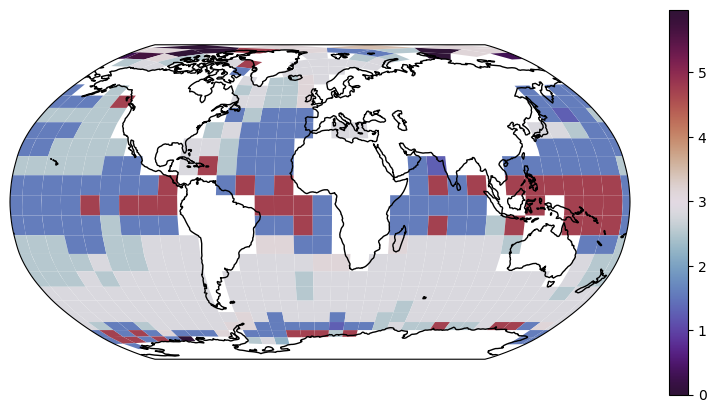

In [65]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()

from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)
# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=bins[max1], cmap='twilight_shifted', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
ax.autoscale_view()
plt.colorbar(coll)
plt.gcf().savefig('angle_SON.png')

In [66]:
#DJF
h = hist_ds['histogram_vort_strain_div'].isel(time=slice(8,17))#.sel(region=230)
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')#.isel(strain_bin=10)
h1['theta'] = np.arctan2(h1['div_bin'],h1['vort_bin'])+np.pi


bins = np.linspace(0, 2*np.pi, 21)
weights=h1.fillna(0)


#MUST FIX THIS SO WE ARE CONSISTENTLY PICKING VALUES WITH strain>f
h2 = histogram(h1['theta'], bins=bins,weights=weights, dim=['div_bin','vort_bin'])
h_gt_f = h2.where(h1.strain_bin>1).sum('strain_bin')
h1_gt_f = h1.where(h1.strain_bin>1).sum('strain_bin')
max1 = h_gt_f.argmax('theta_bin').load()

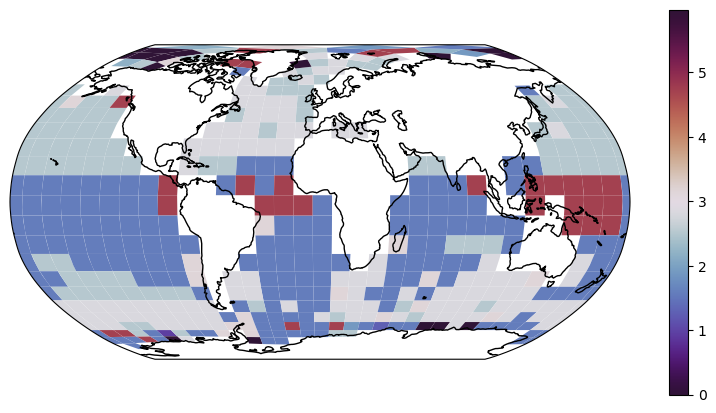

In [67]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()

from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)
# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=bins[max1], cmap='twilight_shifted', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
ax.autoscale_view()
plt.colorbar(coll)
plt.gcf().savefig('angle_DJF.png')


In [68]:
#FMA
h = hist_ds['histogram_vort_strain_div'].isel(time=slice(17,26))#.sel(region=230)
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')#.isel(strain_bin=10)
h1['theta'] = np.arctan2(h1['div_bin'],h1['vort_bin'])+np.pi


bins = np.linspace(0, 2*np.pi, 21)
weights=h1.fillna(0)


#MUST FIX THIS SO WE ARE CONSISTENTLY PICKING VALUES WITH strain>f
h2 = histogram(h1['theta'], bins=bins,weights=weights, dim=['div_bin','vort_bin'])
h_gt_f = h2.where(h1.strain_bin>1).sum('strain_bin')
h1_gt_f = h1.where(h1.strain_bin>1).sum('strain_bin')
max1 = h_gt_f.argmax('theta_bin').load()

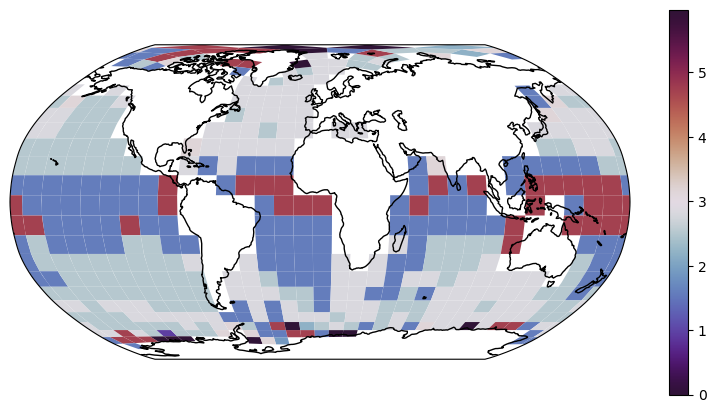

In [69]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()

from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)
# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=bins[max1], cmap='twilight_shifted', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
ax.autoscale_view()
plt.colorbar(coll)
plt.gcf().savefig('angle_FMA.png')

In [70]:
#JJA
h = hist_ds['histogram_vort_strain_div'].isel(time=slice(26,35))#.sel(region=230)
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')#.isel(strain_bin=10)
h1['theta'] = np.arctan2(h1['div_bin'],h1['vort_bin'])+np.pi


bins = np.linspace(0, 2*np.pi, 21)
weights=h1.fillna(0)


#MUST FIX THIS SO WE ARE CONSISTENTLY PICKING VALUES WITH strain>f
h2 = histogram(h1['theta'], bins=bins,weights=weights, dim=['div_bin','vort_bin'])
h_gt_f = h2.where(h1.strain_bin>1).sum('strain_bin')
h1_gt_f = h1.where(h1.strain_bin>1).sum('strain_bin')
max1 = h_gt_f.argmax('theta_bin').load()

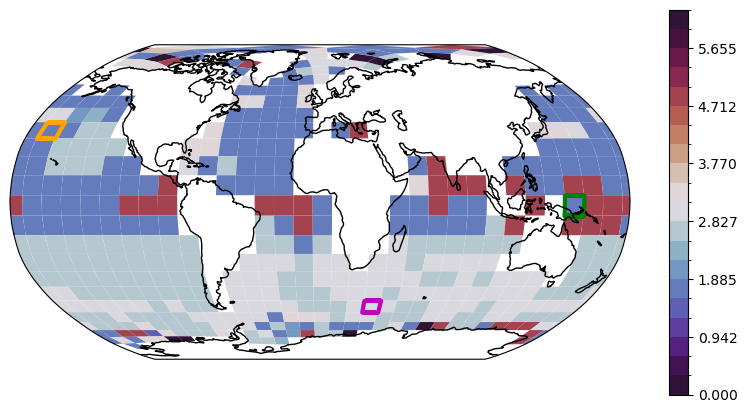

In [157]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()

from matplotlib.collections import PolyCollection
import matplotlib.patches as patches
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)
bounds  = bins
cmap    = mpl.cm.twilight_shifted
norm    = mpl.colors.BoundaryNorm(bounds,cmap.N)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=bins[max1], cmap='twilight_shifted', norm=norm, edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
ax.autoscale_view()

#highlight region
col2 = PolyCollection(verts[60:61], array=bins[max1[60:61]], cmap='twilight_shifted', norm=norm, linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax.add_collection(col2)
ax.autoscale_view()
#verts = np.stack((hist_ds.lon.isel(region=60).values, hist_ds.vertices_latitude.isel(region=60).values),1)
#rect = patches.Rectangle(verts[0],verts[2,0]-verts[0,0] ,verts[2,1]-verts[1,1],linewidth=20, edgecolor='r', facecolor='r',transform=ccrs.PlateCarree())
#ax.add_patch(rect)

col3 = PolyCollection(verts[260:261], array=bins[max1[260:261]], cmap='twilight_shifted', norm=norm, linewidths=3, edgecolors='g', transform=ccrs.PlateCarree())
ax.add_collection(col3)
ax.autoscale_view()

col4 = PolyCollection(verts[232:233], array=bins[max1[232:233]], cmap='twilight_shifted', norm=norm, linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
ax.add_collection(col4)
ax.autoscale_view()

plt.colorbar(coll)
plt.gcf().savefig('angle_JJA.png')


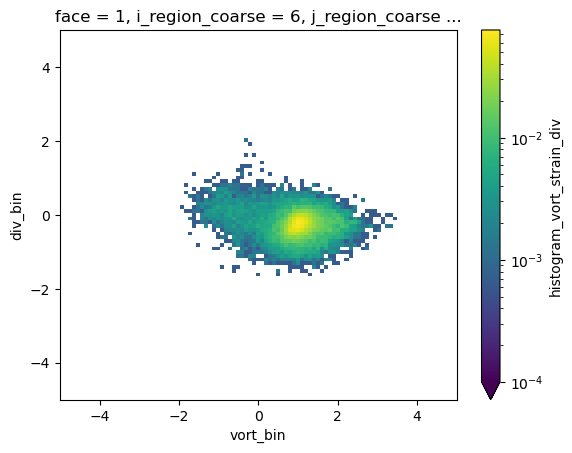

In [140]:
h1_gt_f.isel(region=60).plot(x='vort_bin', vmin=10**-4, norm=mpl.colors.LogNorm())#norm=mpl.colors.LogNorm()

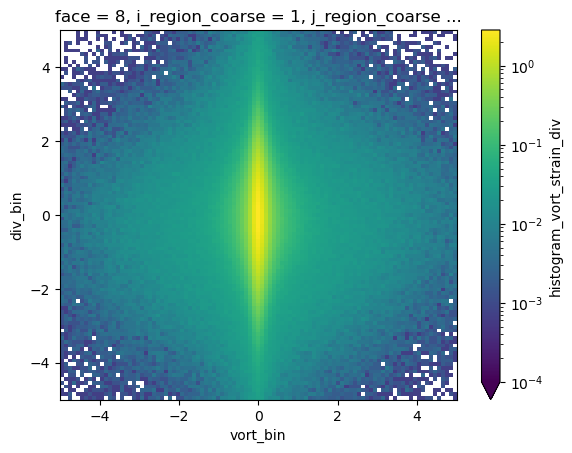

In [146]:
h1_gt_f.isel(region=260).plot(x='vort_bin', vmin=10**-4, norm=mpl.colors.LogNorm())

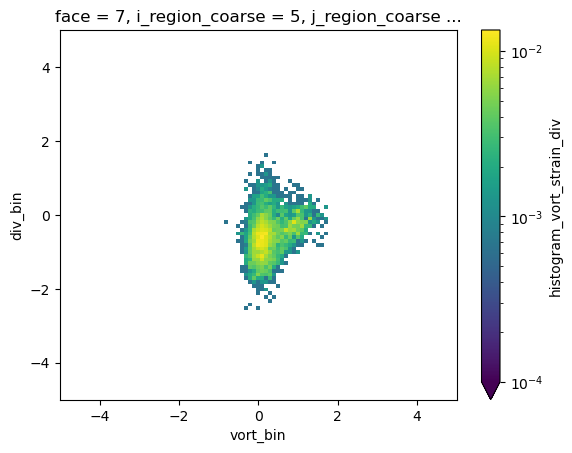

In [158]:
h1_gt_f.isel(region=232).plot(x='vort_bin', vmin=10**-4, norm=mpl.colors.LogNorm())

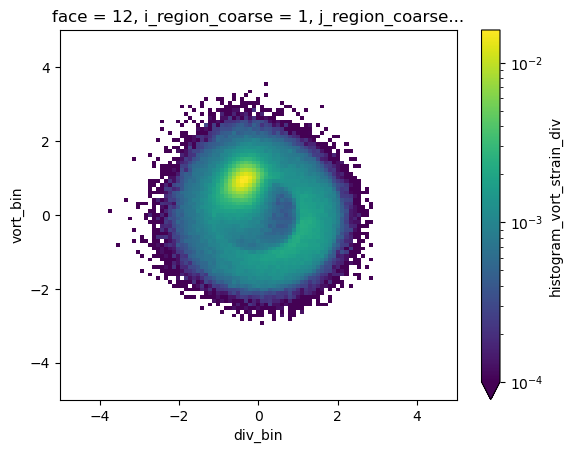

In [48]:
h1.where((h1.strain_bin>1) & (h1.strain_bin<2)).sum('strain_bin').isel(region=419).plot(vmin=10**-4, norm=mpl.colors.LogNorm())

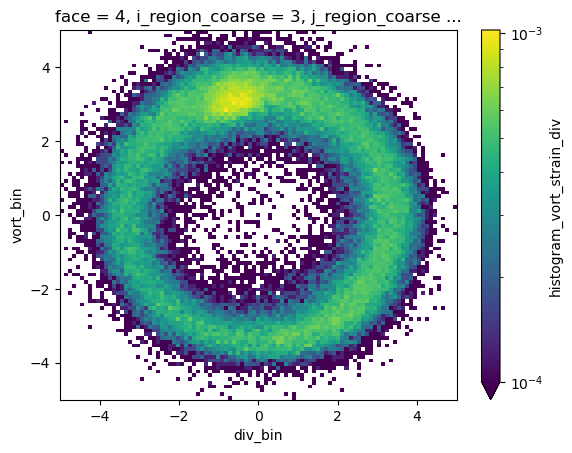

In [235]:
h1.where((h1.strain_bin>3) & (h1.strain_bin<4)).sum('strain_bin').isel(region=138).plot(vmin=10**-4, norm=mpl.colors.LogNorm())

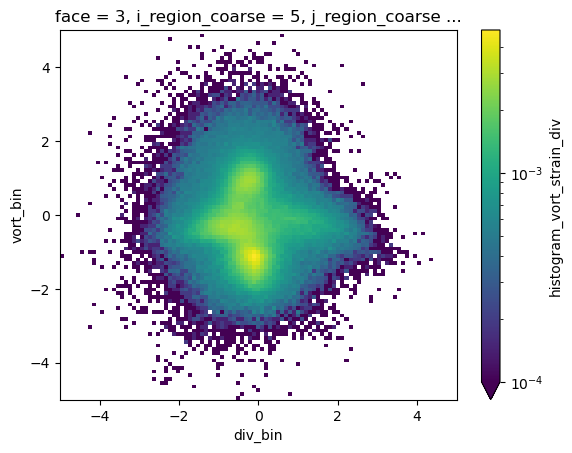

In [55]:
h1.where((h1.strain_bin>1) & (h1.strain_bin<2)).sum('strain_bin').isel(region=108).plot(vmin=10**-4, norm=mpl.colors.LogNorm())

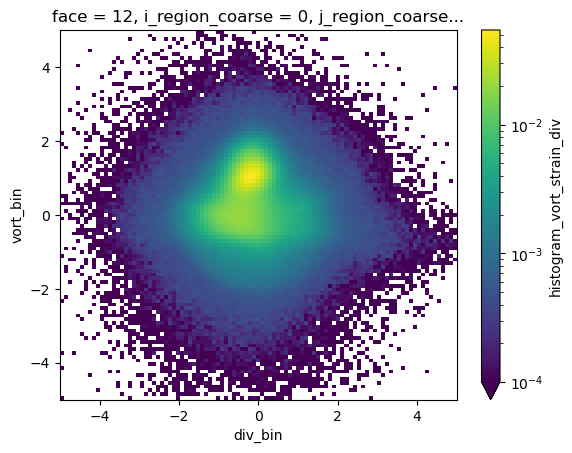

In [49]:
h1.where((h1.strain_bin>1) & (h1.strain_bin<2)).sum('strain_bin').isel(region=418).plot(vmin=10**-4, norm=mpl.colors.LogNorm())

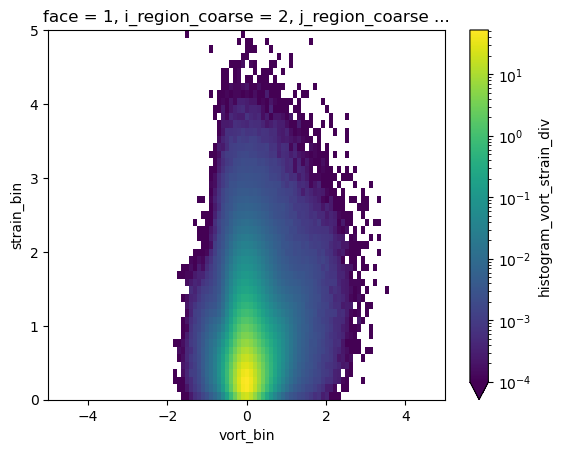

In [112]:
h1.sum('div_bin').isel(region=43).plot(x='vort_bin',vmin=10**-4, norm=mpl.colors.LogNorm())

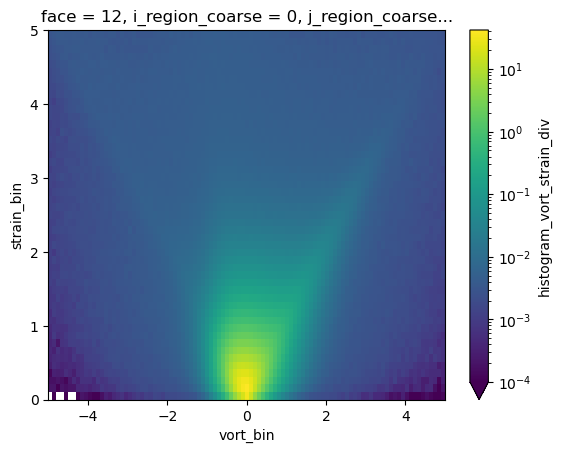

In [44]:
h1.sum('div_bin').isel(region=417).plot(x='vort_bin',vmin=10**-4, norm=mpl.colors.LogNorm())

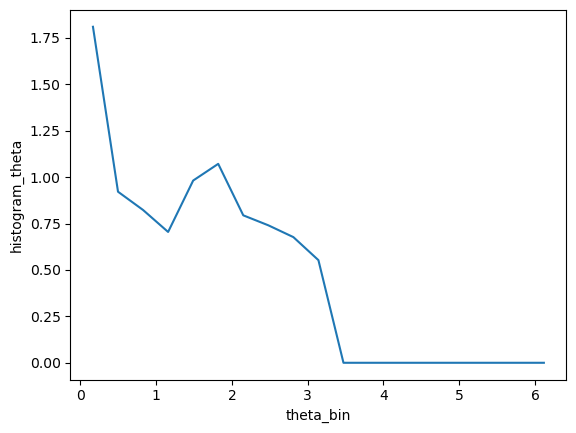

In [116]:
h_gt_f.isel(region=27).plot()

In [53]:
#mode(bins[max1])
vals,counts = np.unique(bins[max1], return_counts=True)

In [54]:
vals

array([0.51291309, 1.28228272, 1.53873926, 1.92342407, 2.30810889,
       2.6927937 , 2.82102197, 2.94925025, 3.07747852, 3.20570679,
       4.61621778, 4.74444605, 4.87267432, 6.15495704])

In [55]:
counts

array([  1,   1, 142,   1,   2, 105,   5, 128,  13,   3,  24,   2,   2,
         9])

In [56]:
bins

array([0.        , 0.12822827, 0.25645654, 0.38468481, 0.51291309,
       0.64114136, 0.76936963, 0.8975979 , 1.02582617, 1.15405444,
       1.28228272, 1.41051099, 1.53873926, 1.66696753, 1.7951958 ,
       1.92342407, 2.05165235, 2.17988062, 2.30810889, 2.43633716,
       2.56456543, 2.6927937 , 2.82102197, 2.94925025, 3.07747852,
       3.20570679, 3.33393506, 3.46216333, 3.5903916 , 3.71861988,
       3.84684815, 3.97507642, 4.10330469, 4.23153296, 4.35976123,
       4.48798951, 4.61621778, 4.74444605, 4.87267432, 5.00090259,
       5.12913086, 5.25735913, 5.38558741, 5.51381568, 5.64204395,
       5.77027222, 5.89850049, 6.02672876, 6.15495704, 6.28318531])

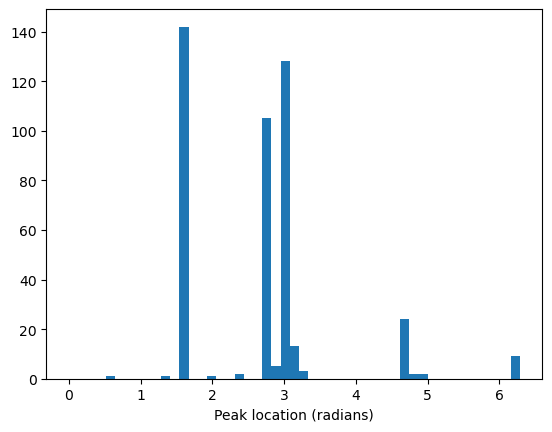

In [48]:
plt.hist(bins[max1],bins=bins)
plt.xlabel('Peak location (radians)')
plt.gcf().savefig('angle_hist.png')

ValueError: not enough values to unpack (expected 2, got 1)

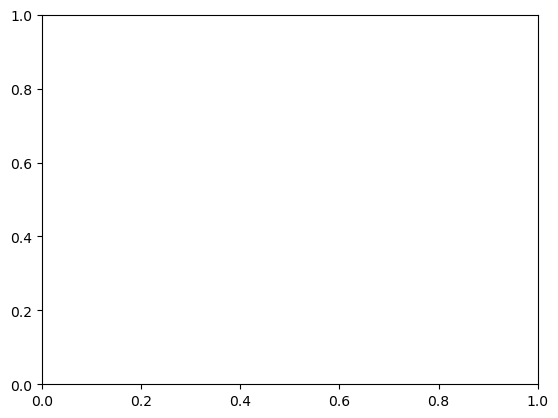

In [21]:
plt.pcolor(hist_ds.vertices_longitude.isel(vertices=0), hist_ds.vertices_latitude.isel(vertices=0), peakiness)

In [67]:
cells_above_f = h_gt_f.sum('theta_bin')

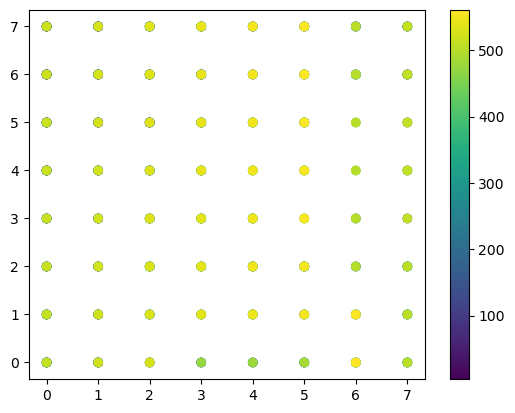

In [18]:
cs = plt.scatter(x=h.i_region_coarse, y=h.j_region_coarse, c=h.region_num)
plt.colorbar(cs)

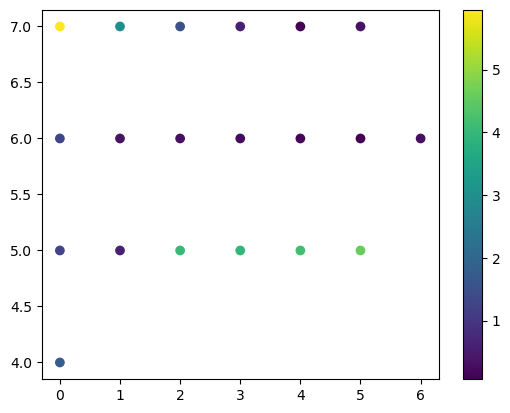

In [68]:
cs = plt.scatter(x=h.i_region_coarse, y=h.j_region_coarse, c=cells_above_f)
plt.colorbar(cs)

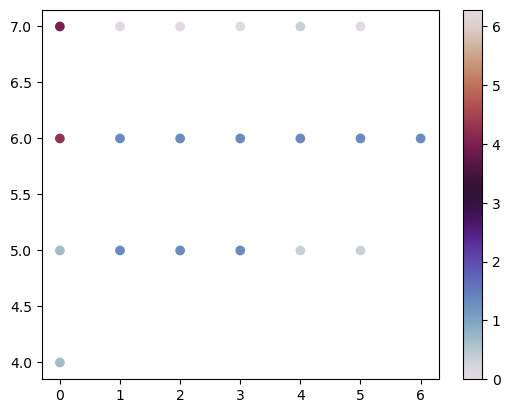

In [63]:
cs = plt.scatter(x=h.i_region_coarse, y=h.j_region_coarse, c=bins[max1], vmax=2*np.pi, vmin=0, cmap='twilight')
plt.colorbar(cs)

In [64]:
hist_ds

<xarray.Dataset> Size: 62GB
Dimensions:                    (div_bin: 99, region: 438, time: 37,
                                vort_bin: 99, strain_bin: 49, vertices: 4)
Coordinates:
  * div_bin                    (div_bin) float64 792B -4.949 -4.848 ... 4.949
    face                       (region) int64 4kB dask.array<chunksize=(13,), meta=np.ndarray>
    i_region_coarse            (region) int64 4kB dask.array<chunksize=(438,), meta=np.ndarray>
    j_region_coarse            (region) int64 4kB dask.array<chunksize=(438,), meta=np.ndarray>
  * region_num                 (region) int64 4kB 4 5 6 7 13 ... 792 793 798 799
  * strain_bin                 (strain_bin) float64 392B 0.05102 ... 4.949
  * time                       (time) datetime64[ns] 296B 2011-09-17T22:30:00...
    vertices_latitude          (vertices, region) float32 7kB dask.array<chunksize=(4, 438), meta=np.ndarray>
    vertices_longitude         (vertices, region) float32 7kB dask.array<chunksize=(4, 438), meta=np.ndarray>
  * vort_bin                   (vort_bin) float64 792B -4.949 -4.848 ... 4.949
Dimensions without coordinates: region, vertices
Data variables:
    histogram_vort_strain_div  (time, region, vort_bin, strain_bin, div_bin) float64 62GB dask.array<chunksize=(1, 1, 99, 49, 99), meta=np.ndarray>

In [21]:
hist_ds.sel(region=130).vertices_latitude.values

array([-57.001026, -57.001026, -50.690105, -50.690105], dtype=float32)

In [27]:
h1.strain_bin

<xarray.DataArray 'strain_bin' (strain_bin: 49)> Size: 392B
array([0.05102 , 0.153061, 0.255102, 0.357143, 0.459184, 0.561224, 0.663265,
       0.765306, 0.867347, 0.969388, 1.071429, 1.173469, 1.27551 , 1.377551,
       1.479592, 1.581633, 1.683673, 1.785714, 1.887755, 1.989796, 2.091837,
       2.193878, 2.295918, 2.397959, 2.5     , 2.602041, 2.704082, 2.806122,
       2.908163, 3.010204, 3.112245, 3.214286, 3.316327, 3.418367, 3.520408,
       3.622449, 3.72449 , 3.826531, 3.928571, 4.030612, 4.132653, 4.234694,
       4.336735, 4.438776, 4.540816, 4.642857, 4.744898, 4.846939, 4.94898 ])
Coordinates:
    face             int64 8B dask.array<chunksize=(), meta=np.ndarray>
    i_region_coarse  int64 8B dask.array<chunksize=(), meta=np.ndarray>
    j_region_coarse  int64 8B dask.array<chunksize=(), meta=np.ndarray>
    region_num       int64 8B 489
  * strain_bin       (strain_bin) float64 392B 0.05102 0.1531 ... 4.847 4.949

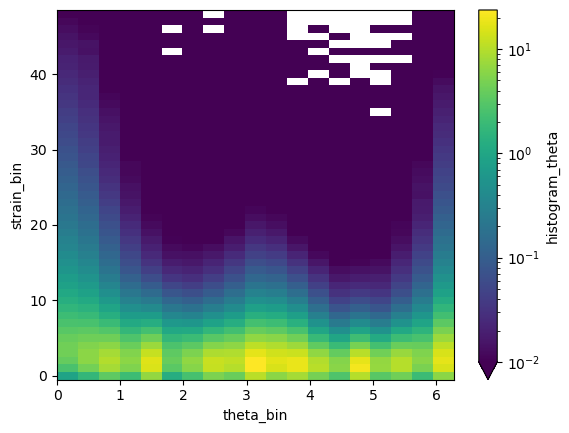

In [24]:
bins = np.linspace(0, 2*np.pi, 20)
weights=h1.fillna(0)
histogram(h1['theta'], bins=bins,weights=weights, dim=['div_bin','vort_bin']).plot(norm=colors.LogNorm(), vmin=1e-2)

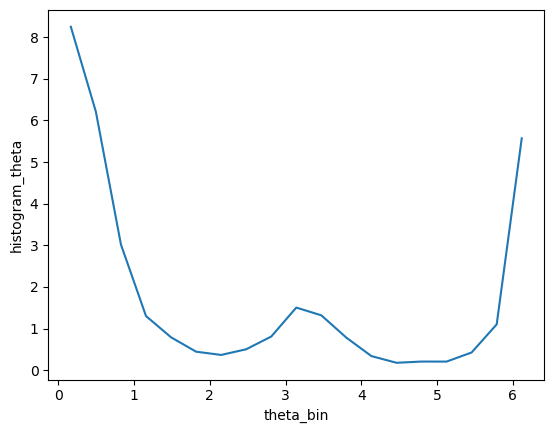

In [32]:
#histogram(h1['theta'], bins=bins,weights=weights, dim=['div_bin','vort_bin']).isel(strain_bin=slice(0,10)).sum('strain_bin').plot()
h_gt_f = histogram(h1['theta'], bins=bins,weights=weights, dim=['div_bin','vort_bin']).isel(strain_bin=slice(10,50)).sum('strain_bin')
#h_gt_f.plot()

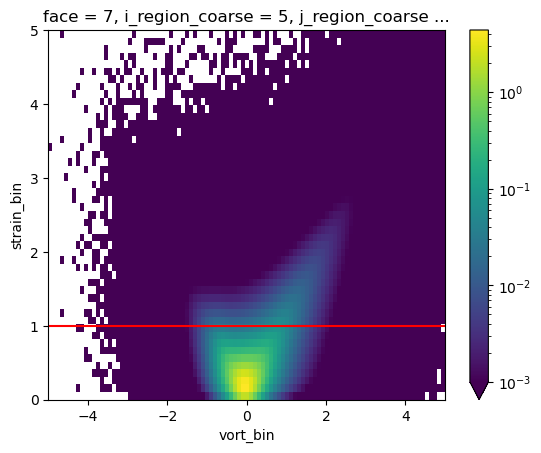

In [85]:
h.isel(region=230).pdf.marginalize('div_bin').mean('time').plot(x='vort_bin',vmin=0.001, norm=mpl.colors.LogNorm())
plt.axhline(1,c = 'r')
plt.gcf().savefig('plan.png')

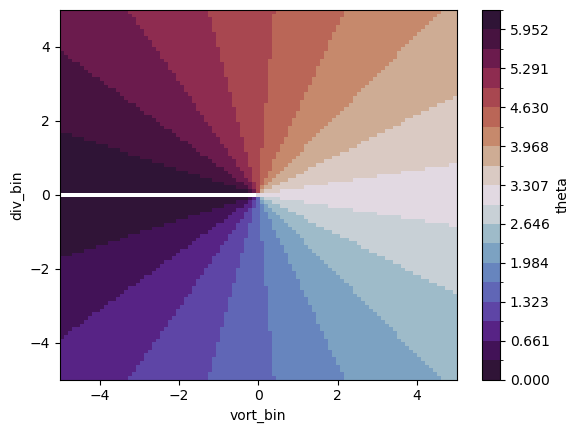

In [55]:
h1['theta'].plot(levels=bins, cmap = 'twilight_shifted')
plt.gcf().savefig('angle_key.png')

In [54]:
bins

array([0.        , 0.33069396, 0.66138793, 0.99208189, 1.32277585,
       1.65346982, 1.98416378, 2.31485774, 2.64555171, 2.97624567,
       3.30693964, 3.6376336 , 3.96832756, 4.29902153, 4.62971549,
       4.96040945, 5.29110342, 5.62179738, 5.95249134, 6.28318531])

## Expectation values

In [70]:
def marginalize(pdf: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Integrate out one or more dimensions of the PDF to remove dependence on that quantity,
    whilst still preserving the total integrated probability.
    """
       
    all_bin_dims = ['vort_bin', 'strain_bin', 'div_bin']
    
    if isinstance(dims, str):
        dims = [dims]
    
    if dims is None:
        dims=all_bin_dims
    
    if any(d not in all_bin_dims for d in dims):
        raise ValueError("Can't take marginal PDF over a dimension which is not a variable of the original PDF")
    
    marginal_pdf = pdf

    # TODO these might be more accurate if we used xarray's integrate function
    if 'vort_bin' in dims:
        vort_bin_width = pdf['vort_bin'].diff('vort_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='vort_bin') * vort_bin_width
        
    if 'strain_bin' in dims:
        strain_bin_width = pdf['strain_bin'].diff('strain_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='strain_bin') * strain_bin_width
        
    if 'div_bin' in dims:
        div_bin_width = pdf['div_bin'].diff('div_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='div_bin') * div_bin_width
        
    return marginal_pdf


def expectation(pdf: xr.DataArray, x: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Take the expectation value of x over the given Probability Density Function.
    """
    
    return marginalize(pdf * x, dims=dims)

In [71]:
@xr.register_dataarray_accessor("pdf")
class DataArrayPDFAccessor:
    def __init__(self, da: xr.DataArray):
        self._da = da
        
    def marginalize(self, dims: str | list = None) -> xr.DataArray:
        return marginalize(self._da, dims=dims)
    
    def expectation(self, x, dims: str | list = None) -> xr.DataArray:
        return expectation(self._da, x, dims=dims)

## Latitude-dependent mean

We want to find the mean of all histograms, but defining the mean in such a way that it varies with latitude but not longitude, i.e. not across all regions.

In [13]:
hist_ds

<xarray.Dataset> Size: 62GB
Dimensions:                    (div_bin: 99, region: 438, time: 37,
                                vort_bin: 99, strain_bin: 49, vertices: 4)
Coordinates:
  * div_bin                    (div_bin) float64 792B -4.949 -4.848 ... 4.949
    face                       (region) int64 4kB dask.array<chunksize=(13,), meta=np.ndarray>
    i_region_coarse            (region) int64 4kB dask.array<chunksize=(438,), meta=np.ndarray>
    j_region_coarse            (region) int64 4kB dask.array<chunksize=(438,), meta=np.ndarray>
  * region_num                 (region) int64 4kB 4 5 6 7 13 ... 792 793 798 799
  * strain_bin                 (strain_bin) float64 392B 0.05102 ... 4.949
  * time                       (time) datetime64[ns] 296B 2011-09-17T22:30:00...
    vertices_latitude          (vertices, region) float32 7kB dask.array<chunksize=(4, 438), meta=np.ndarray>
    vertices_longitude         (vertices, region) float32 7kB dask.array<chunksize=(4, 438), meta=np.ndarray>
  * vort_bin                   (vort_bin) float64 792B -4.949 -4.848 ... 4.949
Dimensions without coordinates: region, vertices
Data variables:
    histogram_vort_strain_div  (time, region, vort_bin, strain_bin, div_bin) float64 62GB dask.array<chunksize=(1, 1, 99, 49, 99), meta=np.ndarray>

In [14]:
# find the latitude of the centrepoint of each region polygon
lat = hist_ds['vertices_latitude'].mean(dim='vertices').rename('center_latitude')
lat

<xarray.DataArray 'center_latitude' (region: 438)> Size: 2kB
dask.array<mean_agg-aggregate, shape=(438,), dtype=float32, chunksize=(438,), chunktype=numpy.ndarray>
Coordinates:
    face             (region) int64 4kB dask.array<chunksize=(13,), meta=np.ndarray>
    i_region_coarse  (region) int64 4kB dask.array<chunksize=(438,), meta=np.ndarray>
    j_region_coarse  (region) int64 4kB dask.array<chunksize=(438,), meta=np.ndarray>
  * region_num       (region) int64 4kB 4 5 6 7 13 14 ... 791 792 793 798 799
Dimensions without coordinates: region

In [15]:
hist_ds.coords['lat'] = lat.load()
hist_ds

<xarray.Dataset> Size: 62GB
Dimensions:                    (div_bin: 99, region: 438, time: 37,
                                vort_bin: 99, strain_bin: 49, vertices: 4)
Coordinates:
  * div_bin                    (div_bin) float64 792B -4.949 -4.848 ... 4.949
    face                       (region) int64 4kB 0 0 0 0 0 0 ... 12 12 12 12 12
    i_region_coarse            (region) int64 4kB 0 0 0 0 1 1 1 ... 2 2 3 3 3 3
    j_region_coarse            (region) int64 4kB 4 5 6 7 5 6 7 ... 6 7 0 1 6 7
  * region_num                 (region) int64 4kB 4 5 6 7 13 ... 792 793 798 799
  * strain_bin                 (strain_bin) float64 392B 0.05102 ... 4.949
  * time                       (time) datetime64[ns] 296B 2011-09-17T22:30:00...
    vertices_latitude          (vertices, region) float32 7kB dask.array<chunksize=(4, 438), meta=np.ndarray>
    vertices_longitude         (vertices, region) float32 7kB dask.array<chunksize=(4, 438), meta=np.ndarray>
  * vort_bin                   (vort_bin) float64 792B -4.949 -4.848 ... 4.949
    lat                        (region) float32 2kB -73.97 -69.45 ... -73.86
Dimensions without coordinates: region, vertices
Data variables:
    histogram_vort_strain_div  (time, region, vort_bin, strain_bin, div_bin) float64 62GB dask.array<chunksize=(1, 1, 99, 49, 99), meta=np.ndarray>

In [16]:
lat_bin_edges = np.arange(start=-90, stop=91, step=10)
lat_bin_edges

array([-90, -80, -70, -60, -50, -40, -30, -20, -10,   0,  10,  20,  30,
        40,  50,  60,  70,  80,  90])

In [17]:
h_vs_lat = hist_ds['histogram_vort_strain_div'].groupby_bins('lat', lat_bin_edges).mean(dim='region').isel(time=0)
h_vs_lat

<xarray.DataArray 'histogram_vort_strain_div' (lat_bins: 18, vort_bin: 99,
                                               strain_bin: 49, div_bin: 99)> Size: 69MB
dask.array<getitem, shape=(18, 99, 49, 99), dtype=float64, chunksize=(1, 99, 49, 99), chunktype=numpy.ndarray>
Coordinates:
  * div_bin     (div_bin) float64 792B -4.949 -4.848 -4.747 ... 4.848 4.949
  * strain_bin  (strain_bin) float64 392B 0.05102 0.1531 0.2551 ... 4.847 4.949
    time        datetime64[ns] 8B 2011-09-17T22:30:00
  * vort_bin    (vort_bin) float64 792B -4.949 -4.848 -4.747 ... 4.848 4.949
  * lat_bins    (lat_bins) object 144B (-90, -80] (-80, -70] ... (80, 90]

In [18]:
h_vs_lat.pdf.expectation(1).load()

<xarray.DataArray (lat_bins: 18)> Size: 144B
array([0.        , 1.0017813 , 1.00757282, 1.01151839, 1.0047085 ,
       1.00905651, 1.01497235, 1.02412999, 1.01651403, 1.01582547,
       1.01898524, 1.00710788, 1.01646905, 1.02777282, 1.01558758,
       1.01121717, 1.00704632, 1.01325677])
Coordinates:
    time        datetime64[ns] 8B 2011-09-17T22:30:00
  * lat_bins    (lat_bins) object 144B (-90, -80] (-80, -70] ... (80, 90]
    vort_bin    float64 8B -4.848
    strain_bin  float64 8B 0.1531
    div_bin     float64 8B -4.848

In [72]:
h_vort_strain_vs_lat = h_vs_lat.pdf.marginalize('div_bin')
h_vort_strain_vs_lat

NameError: name 'h_vs_lat' is not defined

In [20]:
h_vort_strain_vs_lat.pdf.expectation(1, dims=['vort_bin', 'strain_bin']).load()

<xarray.DataArray (lat_bins: 18)> Size: 144B
array([0.        , 1.0017813 , 1.00757282, 1.01151839, 1.0047085 ,
       1.00905651, 1.01497235, 1.02412999, 1.01651403, 1.01582547,
       1.01898524, 1.00710788, 1.01646905, 1.02777282, 1.01558758,
       1.01121717, 1.00704632, 1.01325677])
Coordinates:
    time        datetime64[ns] 8B 2011-09-17T22:30:00
  * lat_bins    (lat_bins) object 144B (-90, -80] (-80, -70] ... (80, 90]
    div_bin     float64 8B -4.848
    vort_bin    float64 8B -4.848
    strain_bin  float64 8B 0.1531

In [21]:
h_vort_strain_vs_lat.sum(dim=['vort_bin', 'strain_bin']).load()

<xarray.DataArray (lat_bins: 18)> Size: 144B
array([ 0.        , 97.19282192, 97.75471455, 98.13751391, 97.47681873,
       97.89866217, 98.47261784, 99.36109145, 98.62219071, 98.5553869 ,
       98.86194824, 97.70960648, 98.61782689, 99.71451862, 98.53230729,
       98.10829024, 97.70363414, 98.3061716 ])
Coordinates:
    time      datetime64[ns] 8B 2011-09-17T22:30:00
  * lat_bins  (lat_bins) object 144B (-90, -80] (-80, -70] ... (70, 80] (80, 90]
    div_bin   float64 8B -4.848

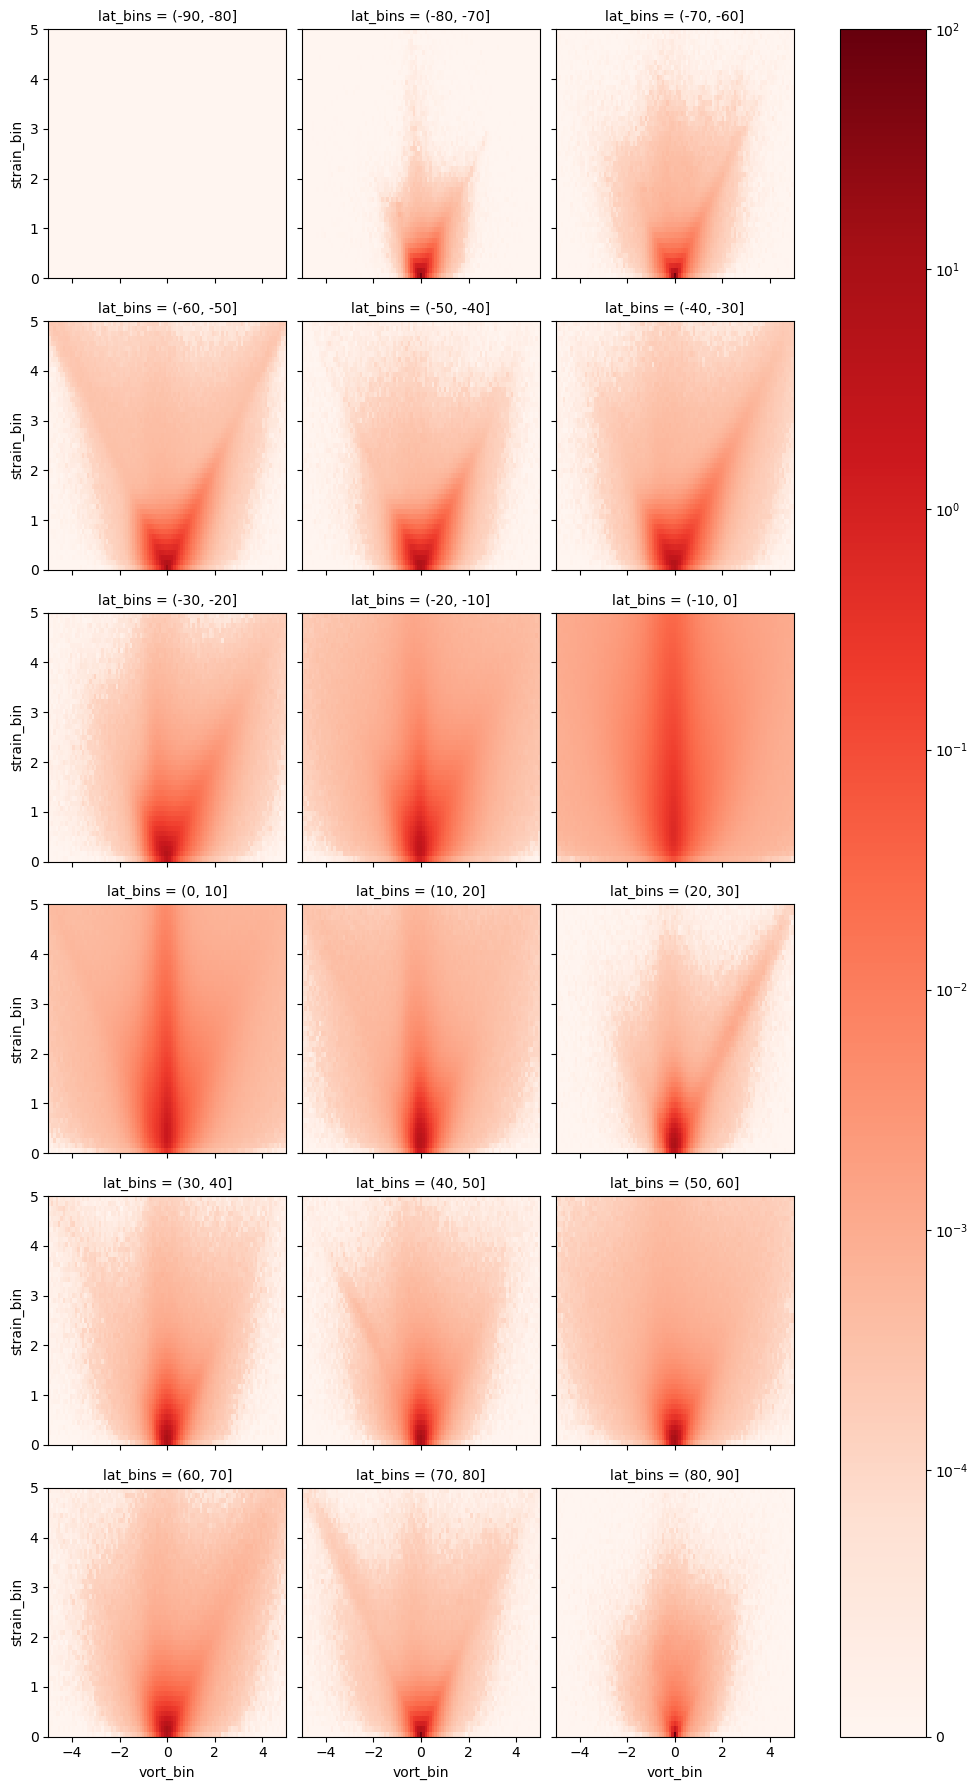

In [22]:
h_vort_strain_vs_lat.plot(x='vort_bin', col='lat_bins', col_wrap=3, vmax=1e2, norm=mpl.colors.SymLogNorm(1e-4), cmap='Reds')